# インド株 ファクター検証 — Step 1: 前処理と分位分析

**対象**: MSCI India IMI（ユニバース、`size` 1/2/3）に対する単一ファクターの有効性検証
**ベンチマーク**: MSCI India（`size` 1/2）

## タイミング規約（`docs/tutorial/00` 準拠）

| 項目 | 規約 |
|---|---|
| スコア | 時点 $t$ のクロスセクション（`factor/core/{t}.pkl`） |
| 評価リターン | 区間 $(t, t+1]$ = `barra/rtn/{t}.pkl` の `lag == 1`（現地通貨 INR・配当込み） |
| 欠損 | `factor/core` / `universe` の巨大負値（$\le -10^8$）は NaN に置換 |
| 標準化 | 毎月のクロスセクションのみで完結（全期間統計は使わない） |

## このノートの流れ

1. パネル構築とカバレッジ確認
2. 前処理: ウィンザライズ → **z-score / Blom 正規スコア**（裾が厚い場合の頑健化）
3. 分位分析（5分位）
   - 分位内 **等ウェイト** vs ベンチマーク等ウェイトの超過リターン
   - 分位内 **時価総額ウェイト** vs ベンチマーク時価総額ウェイトの超過リターン
   - 見せ方: 時系列（累積超過）＋ 年率リターン棒グラフ（バーに銘柄数を表示）

処理はすべて `src/factorlab/` に関数化してあり、ファクター名を差し替えるだけで再実行できる。

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import factorlab as fl

fl.plotting.set_style()
pd.set_option("display.width", 200, "display.max_columns", 60, "display.float_format", lambda v: f"{v:,.4f}")

# ---- 検証対象の設定 ----------------------------------------------------------
FACTOR = "bp_act"          # 実績ベース B/P（バリュー）
FACTOR_LABEL = "B/P (bp_act)"
ASCENDING = True           # True: Q5 = スコア最上位 / False: Q1 = スコア最上位
N_QUANTILE = 5
START, END = 200701, 202607   # 2007年以前はユニバースが 17〜60 銘柄しかないため除外
MIN_UNIVERSE = 0           # スコア保有銘柄数がこれ未満の月は除外（0 = 除外しない）

print(f"factorlab: {ROOT / 'src' / 'factorlab'}")


factorlab: /Users/inu/workspace/india/src/factorlab


## 1. パネル構築

`fl.data.build_panel` が毎月

- `universe/{t}.pkl` から ユニバース（size 1-3）・`cap`（浮動株調整後時価総額 USD）・GICS
- `factor/core/{t}.pkl` から指定ファクター
- `barra/rtn/{t}.pkl` の `lag == 1` から翌月リターン

を結合し、`(yyyymm, bid)` の MultiIndex パネルを返す。`in_bench` は MSCI India（size 1/2）に属するかのフラグ。

In [2]:
panel = fl.data.build_panel([FACTOR], start=START, end=END)
print(panel.shape)
panel.head()


(85493, 11)


gid                      name      gics  size        cap      price  bp_act  fwd_rtn  in_bench sector  log_cap
yyyymm bid                                                                                                                        
200701 INDAAC1  INDAAC1  BAJAJ_HLDGS_&_INVESTMENT  25102020     1 1,905.4562 2,772.1500  0.1854  -0.0554      True     25   7.5525
       INDAAT1  INDAAT1         GRASIM_INDUSTRIES  15102010     1 2,252.9429 2,782.8500  0.1896  -0.2050      True     15   7.7200
       INDAAV1  INDAAV1       HINDALCO_INDUSTRIES  15104020     1 1,942.0812   176.1500  0.4596  -0.2100      True     15   7.5715
       INDAAW1  INDAAW1        HINDUSTAN_UNILEVER  30301010     1 3,640.6247   208.2500  0.0472  -0.1532      True     30   8.1999
       INDAAY1  INDAAY1                       ITC  30203010     1 4,305.0901   174.6000  0.1406  -0.0166      True     30   8.3676

,n_universe,n_bench,n_fwd_rtn,cov_bp_act
mean,363.8000,87.6894,361.0638,0.9991
min,52.0000,52.0000,0.0000,0.9808
max,683.0000,165.0000,683.0000,1.0000


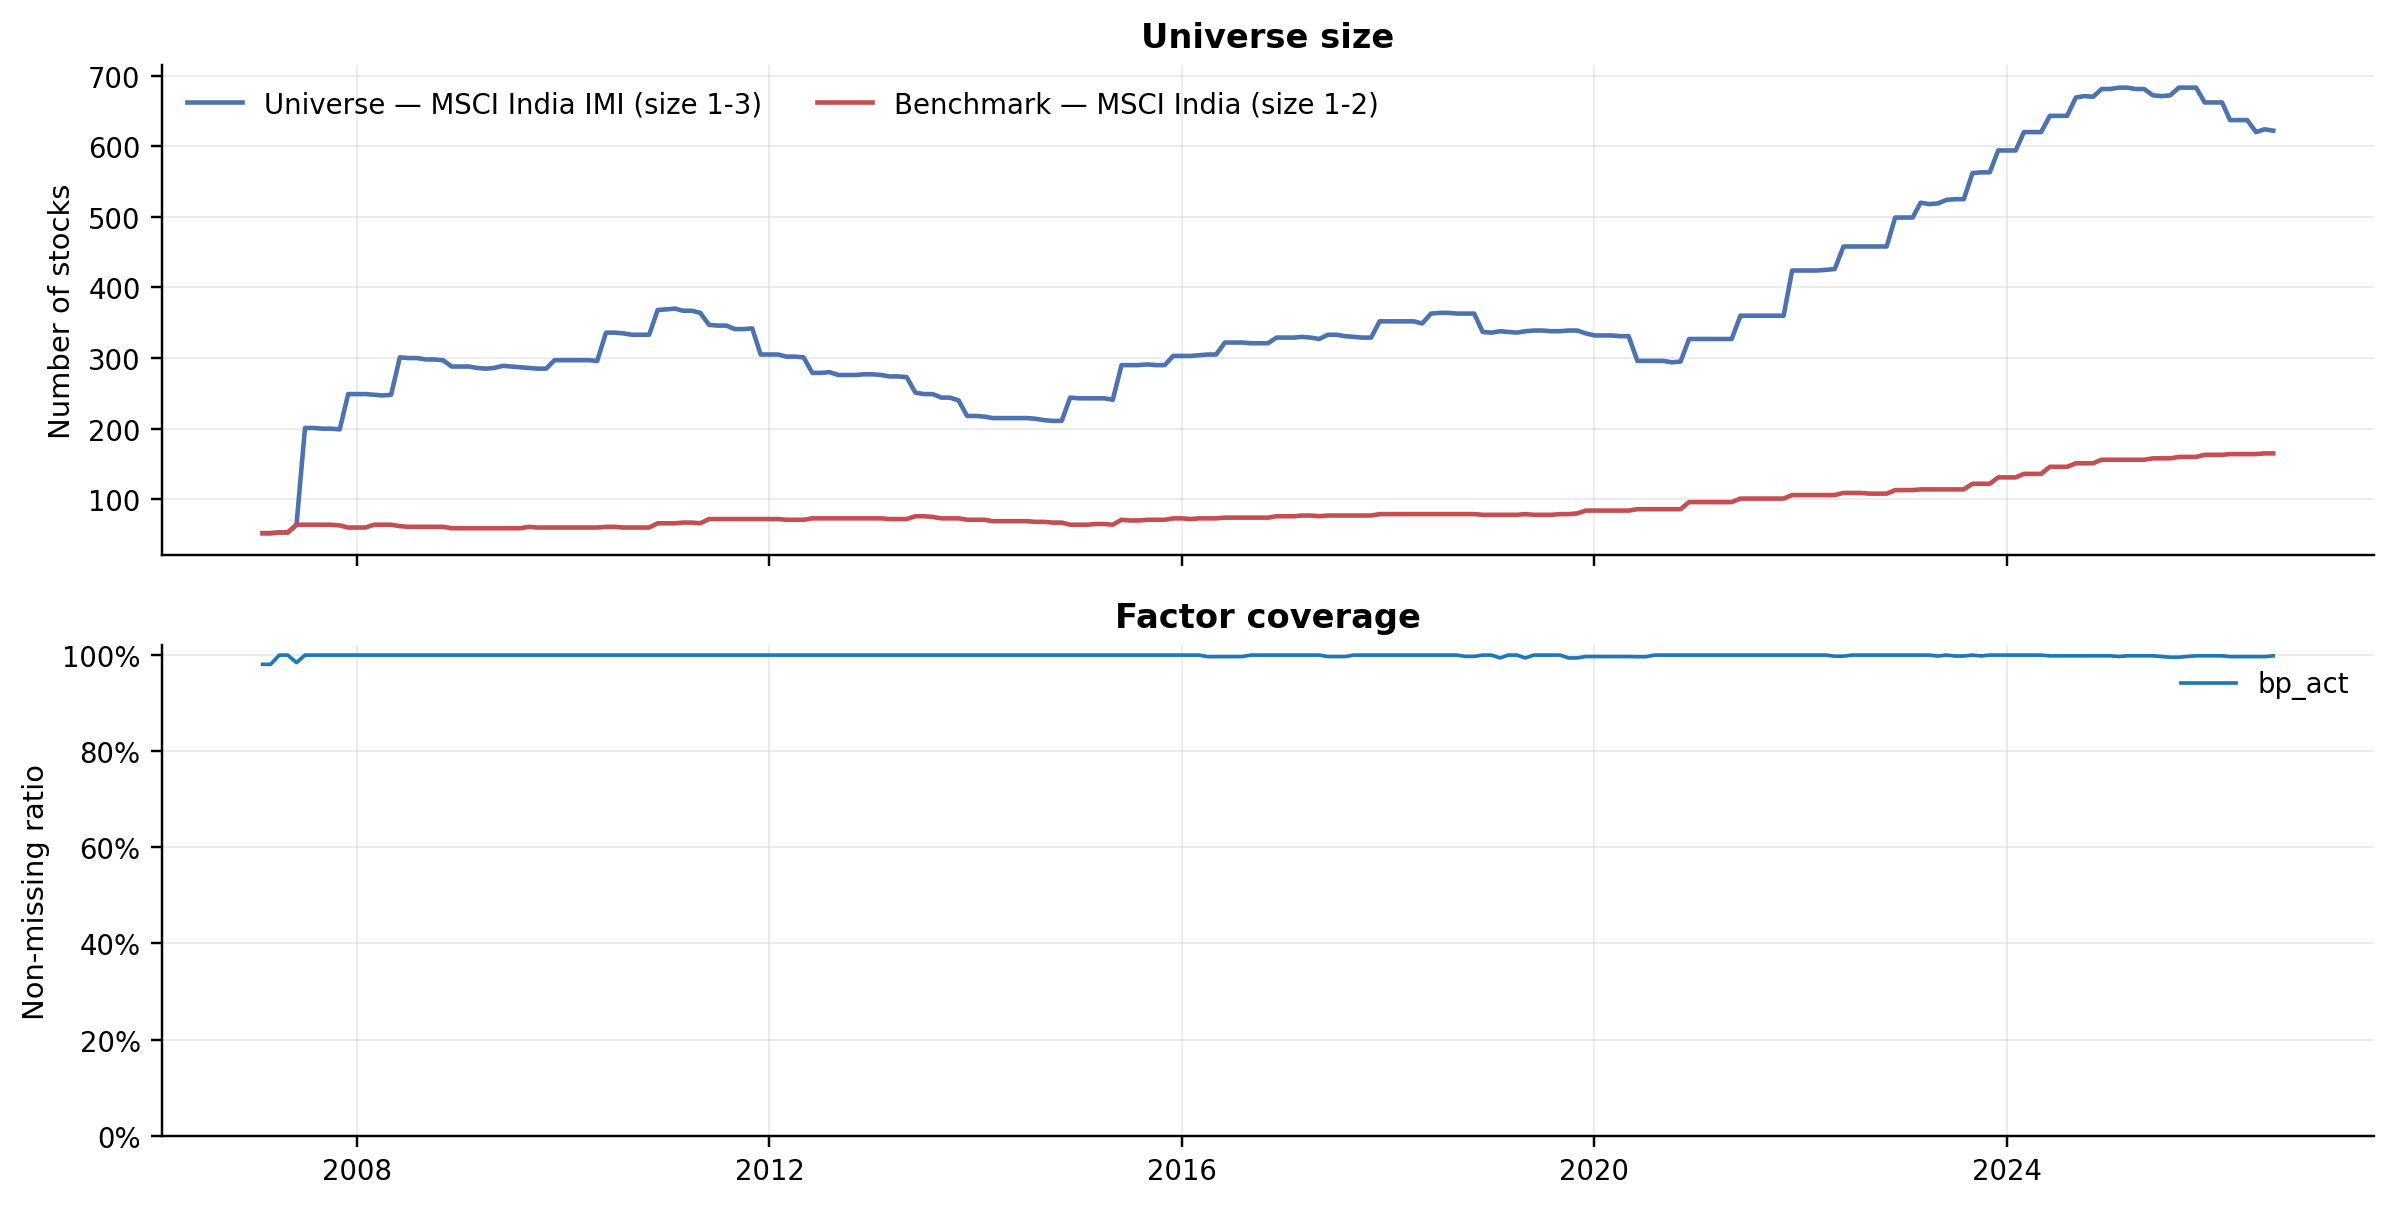

In [3]:
cov = fl.data.coverage(panel, [FACTOR])
display(cov.describe().loc[["mean", "min", "max"]])
fig = fl.plotting.plot_coverage(cov)
fl.plotting.savefig(fig, "01_single_factor/01_coverage");


## 2. 前処理

パイプライン: **ウィンザライズ → 変換（z-score / Blom）**

Blom の正規スコアは、欠損を除いた有効数 $n$ と順位 $r_i$ に対し

$$z_i = \Phi^{-1}\!\left(\frac{r_i - 3/8}{n + 1/4}\right)$$

（同順位は平均順位）。分布形を標準正規に固定するため、裾が厚いファクターでも
外れ値がクロスセクション統計・回帰係数を支配しない。

まず素データの裾の厚さを診断する。

In [4]:
fl.preprocess.tail_stats(panel, [FACTOR])


,coverage,excess_kurt,frac_|z|>3,frac_|z|>5,skew
bp_act,0.9991,18.9761,0.0205,0.0053,2.3982


In [5]:
# winsorize(片側1%) -> z-score  と  Blom を両方作る
panel = fl.preprocess.standardize_panel(panel, FACTOR, method="zscore", winsor=0.01)
panel = fl.preprocess.standardize_panel(panel, FACTOR, method="blom")

fl.preprocess.tail_stats(panel, [FACTOR, f"{FACTOR}_zscore", f"{FACTOR}_blom"])


,skew,excess_kurt,frac_|z|>3,frac_|z|>5,coverage
bp_act,2.3982,18.9761,0.0205,0.0053,0.9991
bp_act_zscore,2.1286,5.6193,0.0246,0.0017,0.9991
bp_act_blom,0.0000,-0.0916,0.0007,0.0000,0.9991


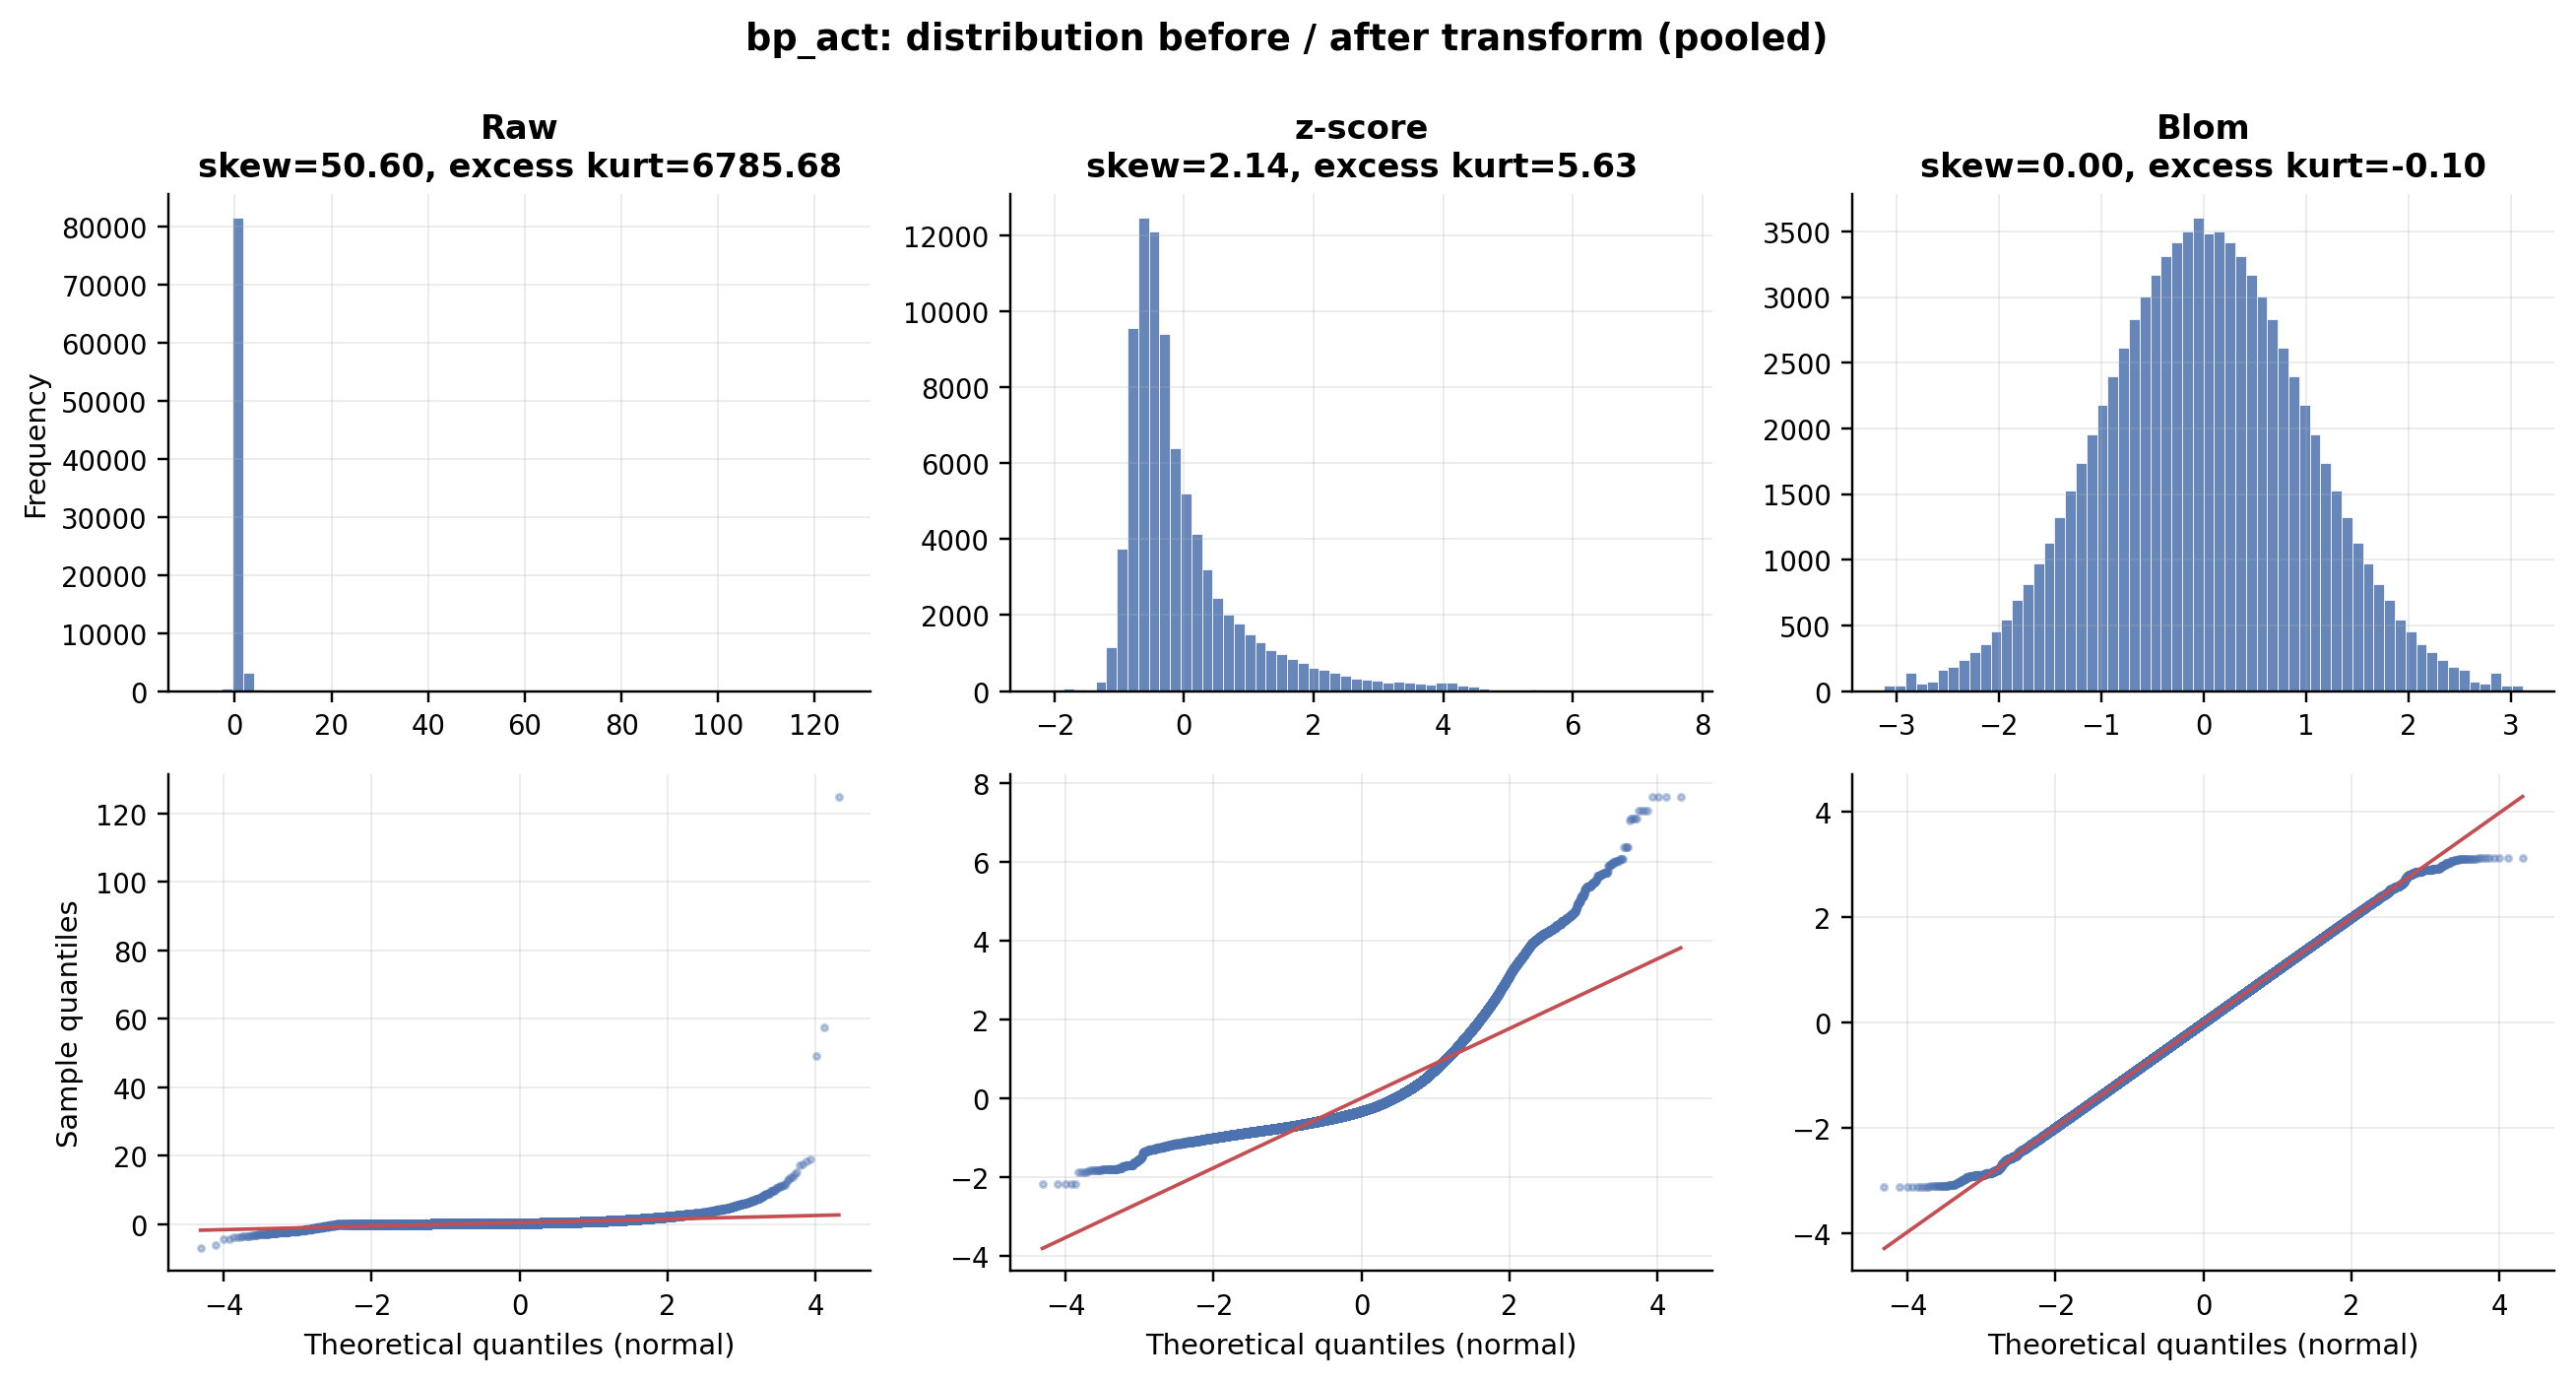

In [6]:
fig = fl.plotting.plot_transform_comparison(panel, FACTOR)
fl.plotting.savefig(fig, "01_single_factor/02_transform");


### 使用するスコアの決定

以降は **Blom 正規スコア** を既定とする（裾の厚いファクターでも同じ扱いができるため）。
`SCORE` を `f"{FACTOR}_zscore"` に変えれば z-score 版で全て再実行できる。

In [7]:
SCORE = f"{FACTOR}_blom"


## 3. 分位分析（5分位）

各月にユニバース（IMI）のスコアで 5 分位に分割し（**Q5 = スコア最上位、Q1 = 最下位**）、翌月リターンを

- **EW**: 分位内 等ウェイト  vs  ベンチマーク（MSCI India）等ウェイト
- **CW**: 分位内 時価総額ウェイト  vs  ベンチマーク時価総額ウェイト

の 2 通りで集計する。EW と CW の差は「効果がサイズ由来かどうか」の診断になる
（`docs/tutorial/07` 7.1 のウェイト規約）。

**分位割当**: 一様順位 $u_i = (r_i - 0.5)/n$ を $[0,1]$ の等分割で切る。
$u$ は順序反転で $1-u$ に写るため、昇順・降順で分位が厳密に鏡像になる
（`ceil(rank * q / n)` 方式は $n$ が $q$ で割り切れない月に非対称が出る）。

**期間**: 2007年以前はユニバースが 17〜60 銘柄（分位あたり 3〜12 銘柄）で
`docs/tutorial/07` の目安（分位あたり 30 銘柄）を大きく下回るため、`START = 200701` としている。
さらに月単位で絞りたい場合は `MIN_UNIVERSE` を使う。

In [8]:
res = fl.quantile.quantile_returns(panel, SCORE, q=N_QUANTILE, ascending=ASCENDING,
                                   min_universe=MIN_UNIVERSE)
summaries = {w: fl.quantile.quantile_summary(res, weighting=w) for w in ("ew", "cw")}

print("=== EW: 分位内 等ウェイト vs ベンチマーク等ウェイト ===")
display(summaries["ew"])
print("=== CW: 分位内 時価総額ウェイト vs ベンチマーク時価総額ウェイト ===")
display(summaries["cw"])
print("単調性（Spearman, +1 が Q1->Q5 完全単調増加 = 良好）:",
      {w: round(fl.quantile.monotonicity(summaries[w], N_QUANTILE), 3) for w in ("ew", "cw")})


=== EW: 分位内 等ウェイト vs ベンチマーク等ウェイト ===


,ann_return,ann_excess,ann_excess_arith,ann_vol,te,IR,t_stat_NW,hit_ratio,max_dd,max_dd_excess,turnover_1way,turnover_ann,name_turnover,n_stocks_mean,n_stocks_min
Q1,0.0986,-0.0128,-0.0134,0.2271,0.0981,-0.1367,-0.6374,0.5128,-0.6989,-0.4128,0.1186,1.4230,0.0892,72.4573,10.0000
Q2,0.1253,0.0139,0.0151,0.2482,0.0845,0.1787,0.7905,0.5128,-0.6962,-0.2210,0.1964,2.3566,0.1710,72.4786,10.0000
Q3,0.0970,-0.0143,-0.0021,0.2826,0.1035,-0.0204,-0.0861,0.4744,-0.7286,-0.4188,0.2186,2.6227,0.1938,72.4487,11.0000
Q4,0.1039,-0.0075,0.0131,0.3144,0.1229,0.1068,0.4591,0.5085,-0.7211,-0.4318,0.1985,2.3818,0.1703,72.4786,10.0000
Q5,0.0798,-0.0316,0.0062,0.3637,0.1761,0.0352,0.1557,0.4786,-0.7534,-0.7448,0.1223,1.4676,0.0850,72.4359,10.0000
Q5-Q1,-0.0020,-0.0020,0.0196,0.2137,0.2137,0.0918,0.4009,0.4615,-0.7625,-0.7625,0.2409,2.8906,NaN,NaN,NaN
NA,0.2214,0.1100,0.2906,0.5852,0.5274,0.5509,1.4313,0.4561,-0.5387,-0.4315,0.1333,1.5995,0.2827,0.3077,0.0000
bench,0.1114,NaN,NaN,0.2385,NaN,NaN,NaN,NaN,-0.6234,NaN,NaN,NaN,NaN,NaN,NaN


=== CW: 分位内 時価総額ウェイト vs ベンチマーク時価総額ウェイト ===


,ann_return,ann_excess,ann_excess_arith,ann_vol,te,IR,t_stat_NW,hit_ratio,max_dd,max_dd_excess,turnover_1way,turnover_ann,name_turnover,n_stocks_mean,n_stocks_min
Q1,0.1061,-0.0055,-0.0079,0.1948,0.0970,-0.0817,-0.4414,0.5342,-0.6276,-0.3883,0.0902,1.0827,0.0892,72.4573,10.0000
Q2,0.1426,0.0309,0.0346,0.2463,0.1156,0.2988,1.4107,0.5256,-0.5984,-0.2644,0.1928,2.3133,0.1710,72.4786,10.0000
Q3,0.1047,-0.0069,0.0081,0.2723,0.1110,0.0731,0.3552,0.4829,-0.6731,-0.4353,0.2163,2.5958,0.1938,72.4487,11.0000
Q4,0.1068,-0.0049,0.0147,0.2959,0.1404,0.1044,0.4670,0.4615,-0.6684,-0.3283,0.2113,2.5360,0.1703,72.4786,10.0000
Q5,0.1137,0.0021,0.0371,0.3451,0.2040,0.1819,0.7806,0.4872,-0.6491,-0.6613,0.1488,1.7855,0.0850,72.4359,10.0000
Q5-Q1,0.0127,0.0127,0.0450,0.2617,0.2617,0.1721,0.7869,0.4829,-0.7997,-0.7997,0.2390,2.8682,NaN,NaN,NaN
NA,0.2556,0.1440,0.3281,0.5793,0.5198,0.6313,1.5966,0.4737,-0.5387,-0.4470,0.1392,1.6700,0.2827,0.3077,0.0000
bench,0.1117,NaN,NaN,0.2102,NaN,NaN,NaN,NaN,-0.5956,NaN,NaN,NaN,NaN,NaN,NaN


単調性（Spearman, +1 が Q1->Q5 完全単調増加 = 良好）: {'ew': 0.3, 'cw': 0.7}


### 3.1 時系列（累積超過リターン）

図中のタイトル・軸ラベル・凡例は英語で統一している。

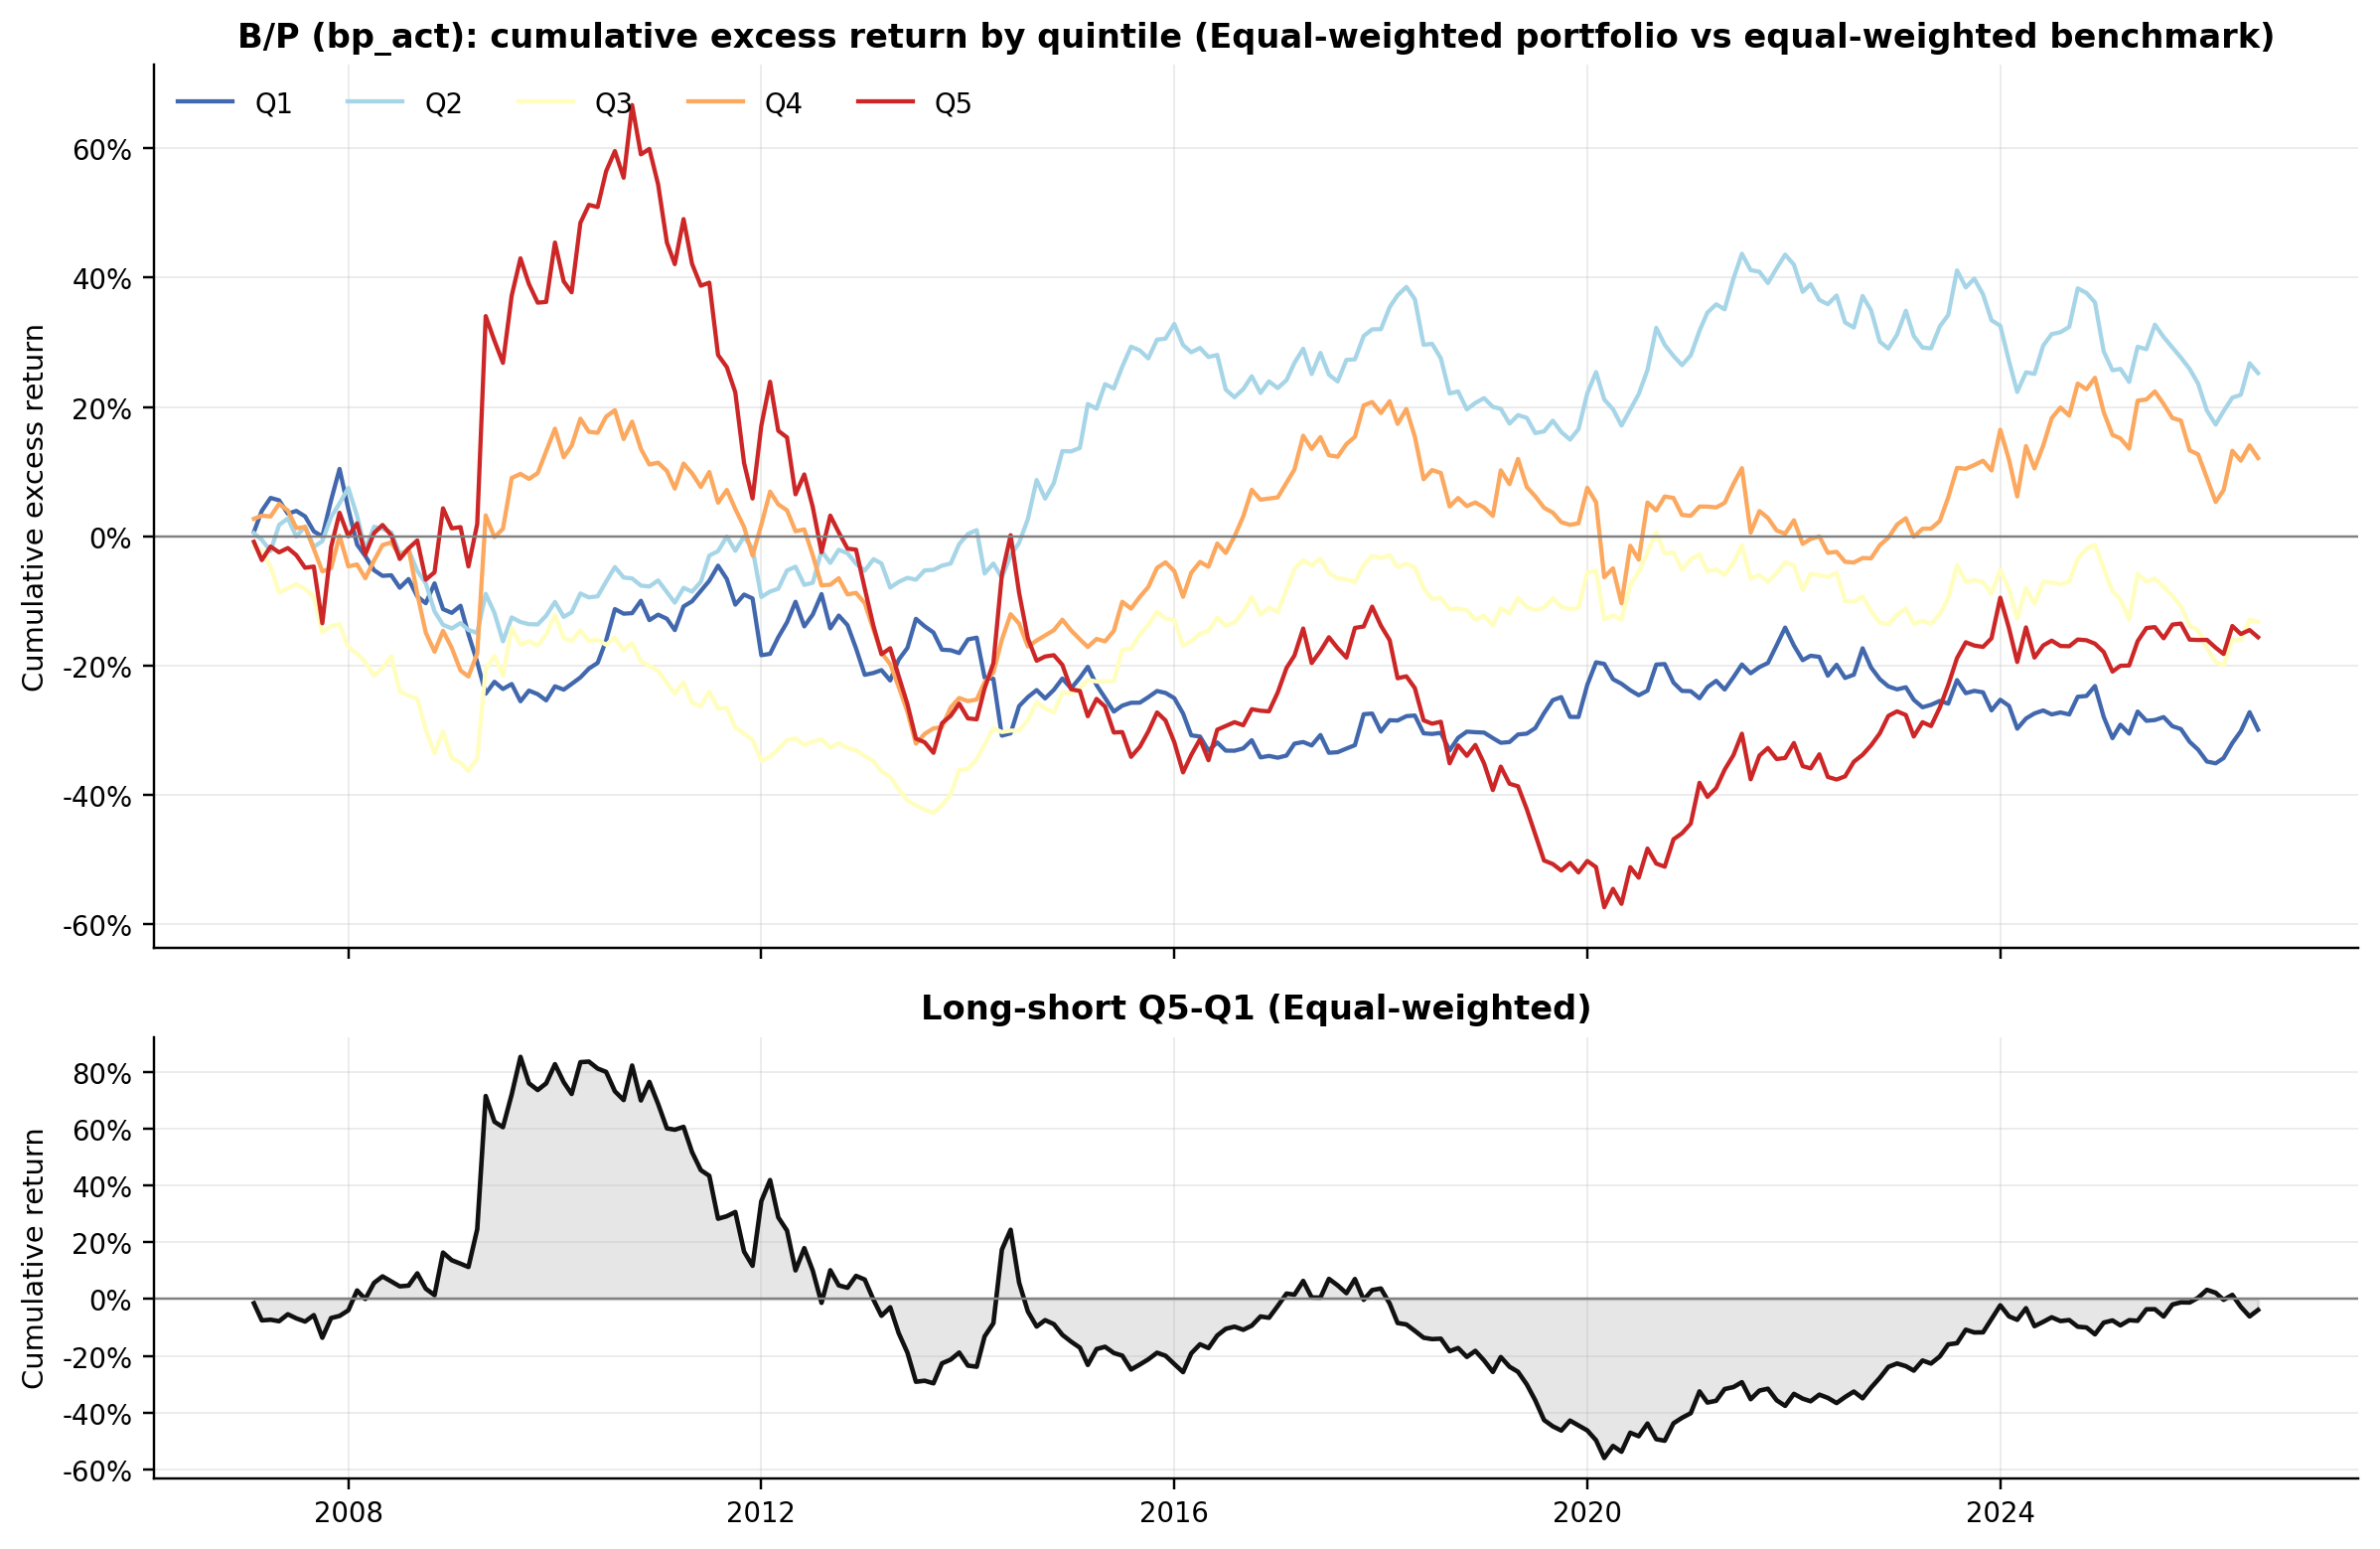

In [9]:
fig = fl.plotting.plot_quantile_timeseries(res, weighting="ew", q=N_QUANTILE, factor=FACTOR_LABEL)
fl.plotting.savefig(fig, "01_single_factor/03_quantile_ts_ew");


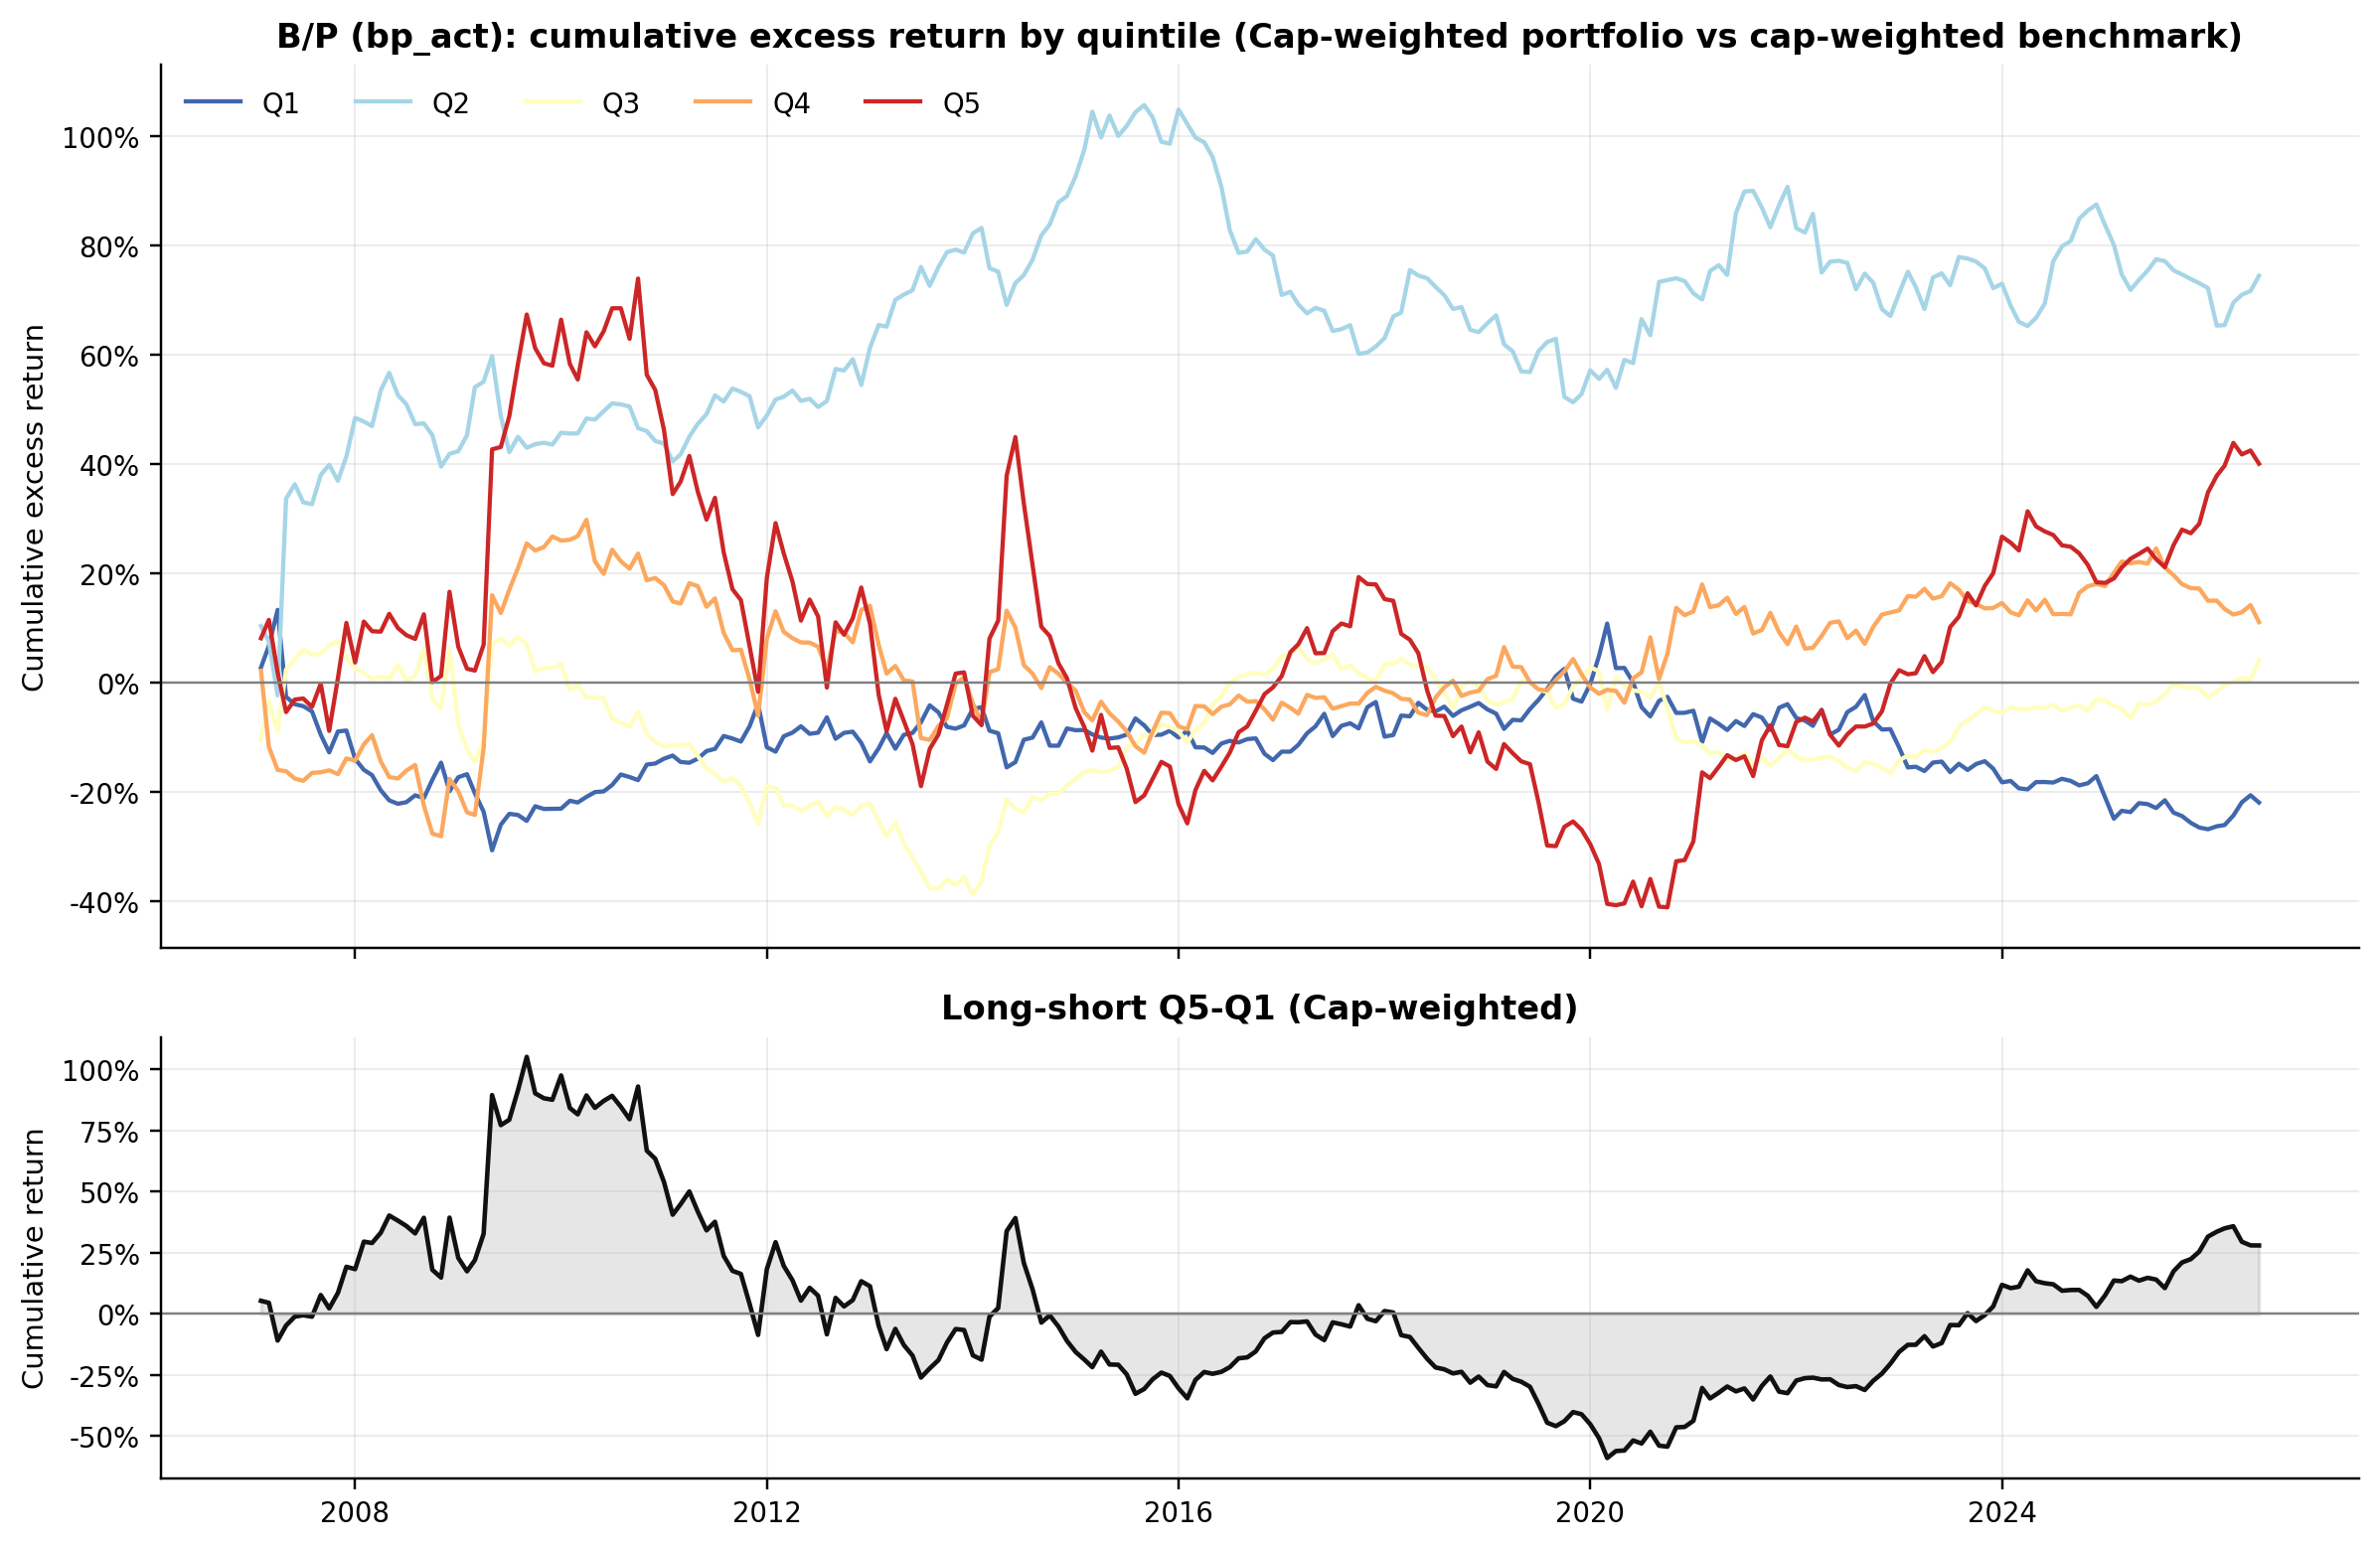

In [10]:
fig = fl.plotting.plot_quantile_timeseries(res, weighting="cw", q=N_QUANTILE, factor=FACTOR_LABEL)
fl.plotting.savefig(fig, "01_single_factor/04_quantile_ts_cw");


### 3.2 年率リターン棒グラフ（バーに銘柄数）

棒の値は **幾何平均年率の超過リターン**（`ann_excess` = 分位ポートの幾何年率 − ベンチマークの幾何年率）。
分位ごとにボラティリティが異なるため、幾何にはボラティリティ・ドラッグが含まれる点に留意
（純粋なシグナルの強さを見たい場合は `value_col="ann_excess_arith"` に切り替え）。

バーの注記: x軸ラベルの2行目 = 分位内の平均銘柄数、バー外側 = 値と Newey-West t 値。

**t 値の符号について**: t 値は「月次超過リターン（算術平均）が 0 か」の検定であり、
棒の値（幾何年率）とは分位ごとのボラティリティ差の分だけズレる。
高ボラ分位では「算術平均はプラス（t > 0）だが幾何年率はマイナス」が起こり得る。

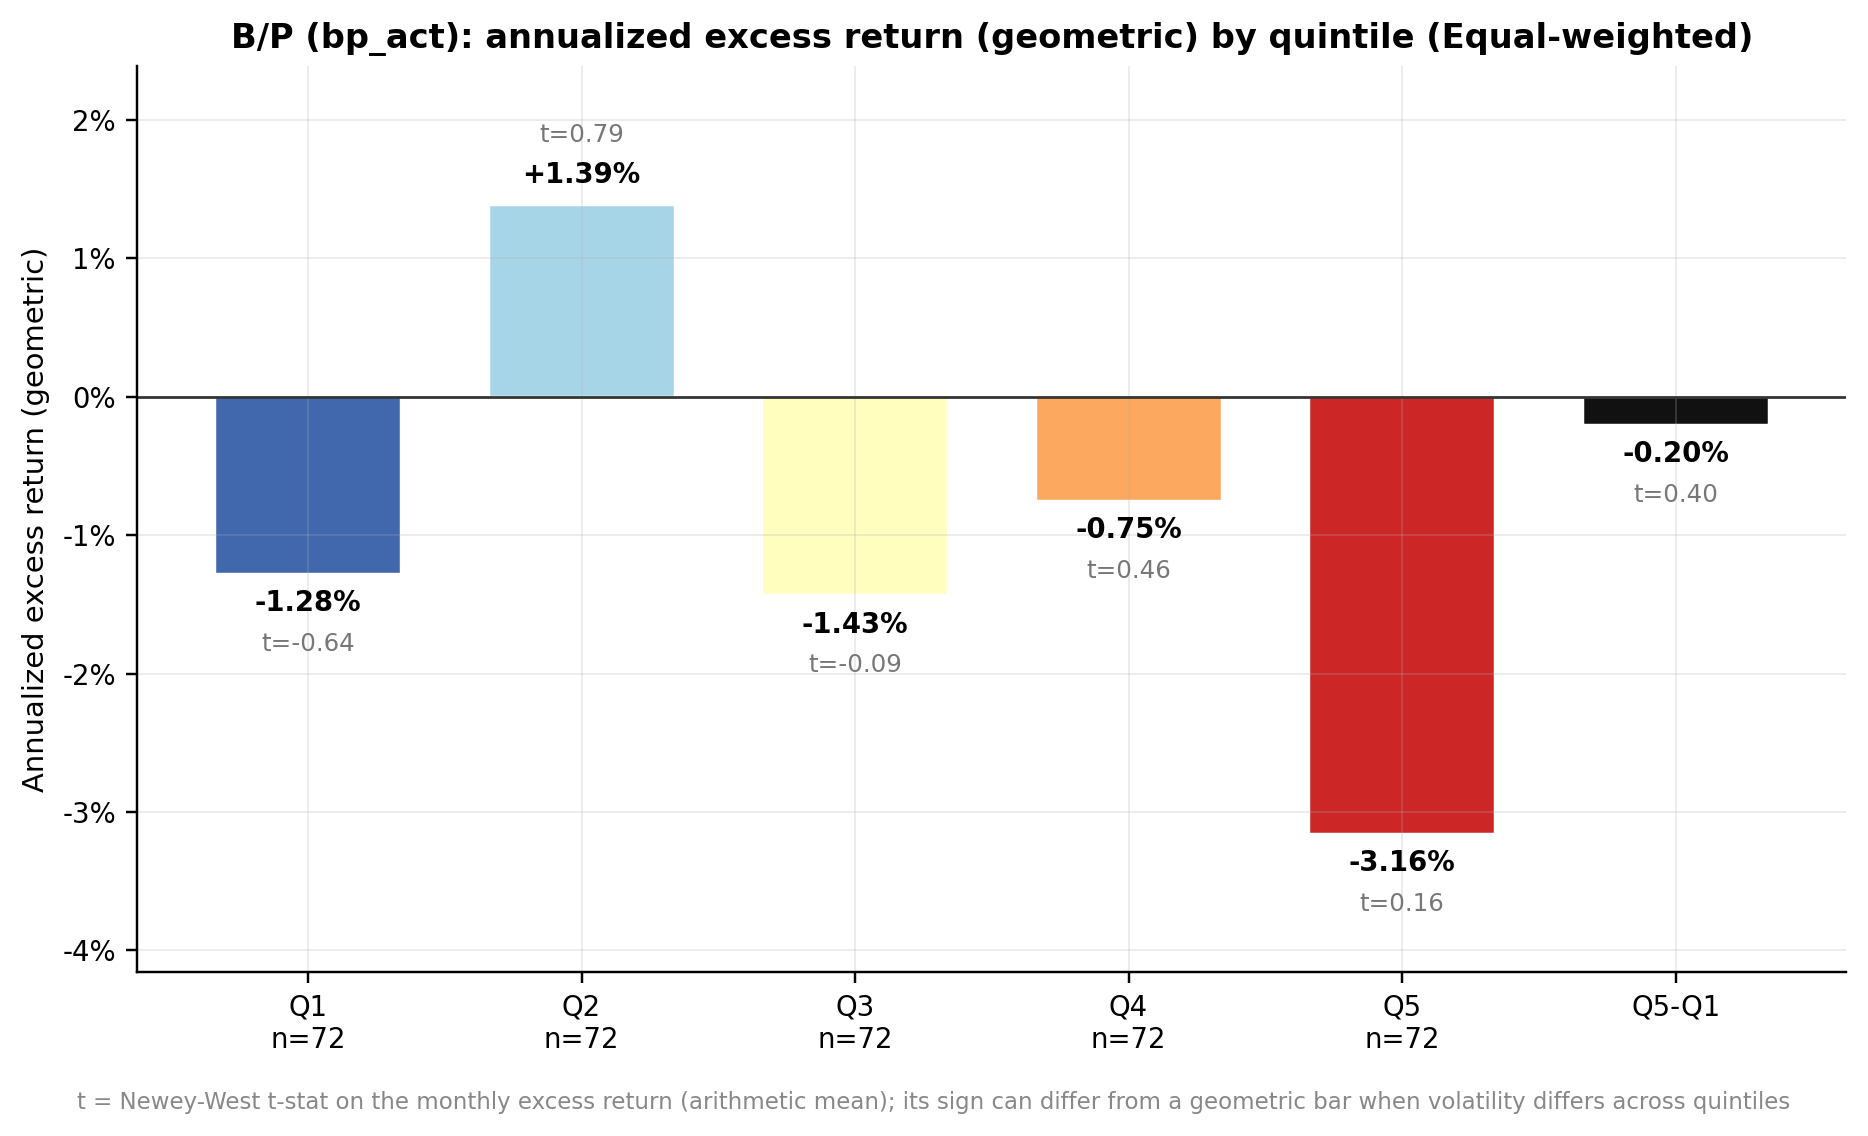

In [11]:
fig = fl.plotting.plot_quantile_bar(summaries["ew"], res["counts"], q=N_QUANTILE,
                                    factor=FACTOR_LABEL, weighting="ew")
fl.plotting.savefig(fig, "01_single_factor/05_quantile_bar_ew");


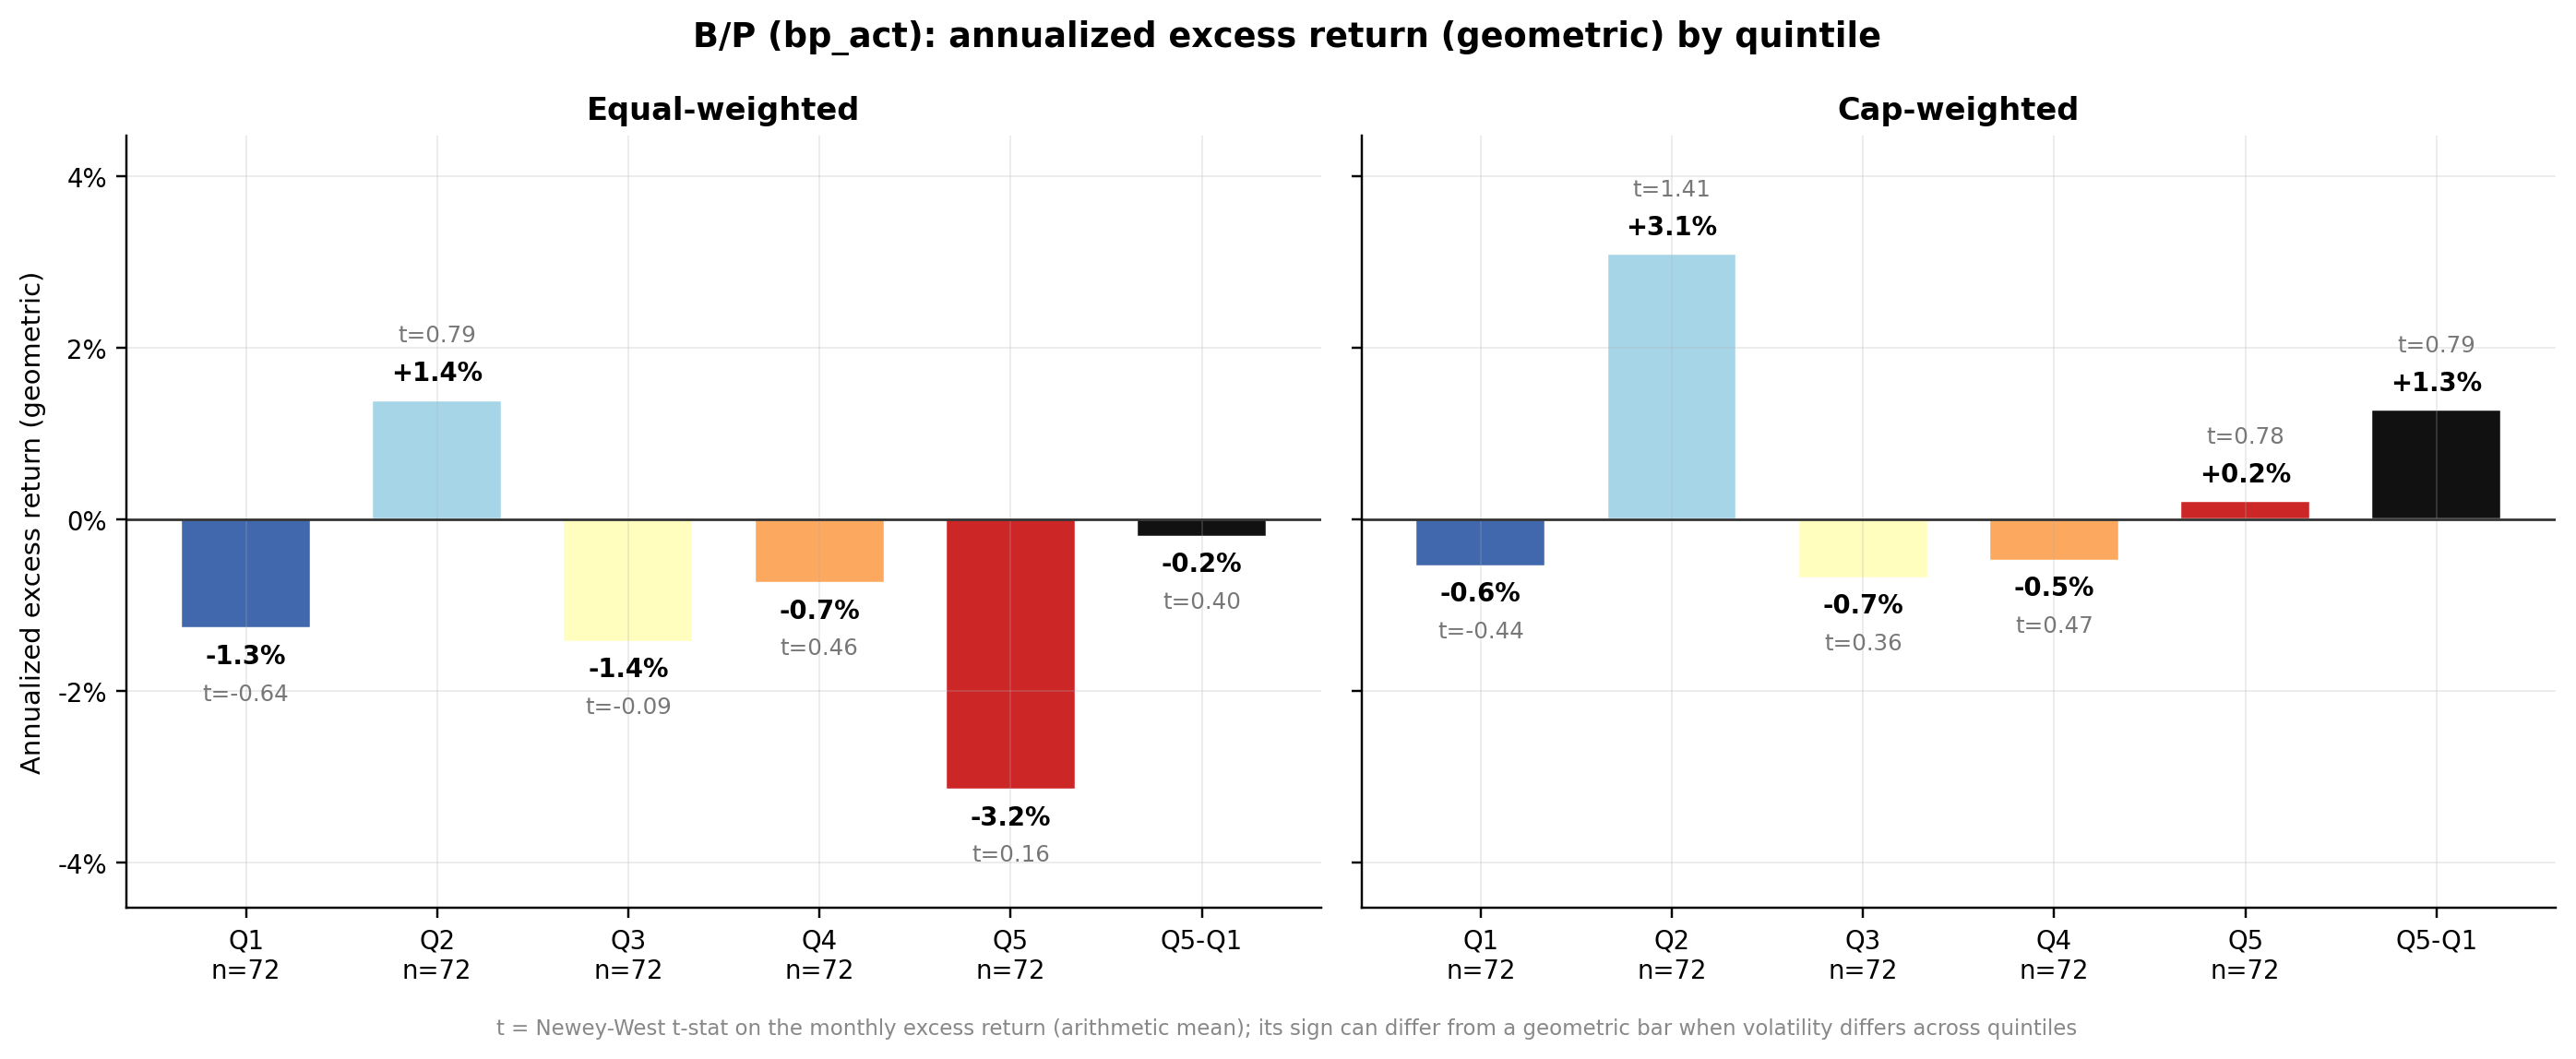

In [12]:
fig = fl.plotting.plot_quantile_panel(res, summaries, q=N_QUANTILE, factor=FACTOR_LABEL)
fl.plotting.savefig(fig, "01_single_factor/06_quantile_bar_both");


### 3.3 リスクと回転率

分位ポートフォリオは「実際に組める形」なので、超過リターンだけでなく
実装上のコストとリスクを合わせて見る。

| 指標 | 定義 | 見どころ |
|---|---|---|
| `te` | 月次超過リターンの年率標準偏差 | アクティブリスク。IR の分母 |
| `IR` | `ann_excess_arith` / `te` | 単位アクティブリスクあたりの超過リターン |
| `ann_vol` | 分位ポート自身の年率ボラ | 絶対リスク。分位間で大きく違うと幾何年率が歪む |
| `max_dd` | 分位ポート自身の最大DD | 絶対の痛み |
| `max_dd_excess` | 累積超過リターン系列の最大DD | **対ベンチでどれだけ劣後し続けたか**。アクティブ運用で効く方 |
| `turnover_1way` / `turnover_ann` | 片道回転率（月次 / 年率） | 実装コストの主要因 |
| `name_turnover` | 分位メンバーの入れ替わり率 | ウェイトではなく銘柄の入替ペース |

**回転率の定義**: 期中の価格変動でウェイトがドリフトすることを考慮した片道回転率

$$\text{turnover}_t = \frac{1}{2} \sum_i \big| w_{i,t} - \tilde w_{i,t^-} \big|,
\qquad \tilde w_{i,t^-} = \frac{w_{i,t-1}(1 + r_{i,t-1 \to t})}{\sum_j w_{j,t-1}(1 + r_{j,t-1 \to t})}$$

ドリフトを無視すると等ウェイトポートの回転率が過大に出る（`docs/tutorial` 1.4）。
ロングショートは両レッグの合計。

**目安**: スコアに情報がなくランダムなら、$q$ 分位の片道回転率は $1 - 1/q$（5分位なら 0.80）に収束する。
これより十分低ければ「スコアが持続的」＝低回転で実装できる、と読める。

In [13]:
cols = ["ann_return", "ann_excess", "ann_vol", "te", "IR", "max_dd", "max_dd_excess",
        "turnover_1way", "turnover_ann", "name_turnover", "n_stocks_mean"]
print("=== EW ===")
display(summaries["ew"][cols])
print("=== CW ===")
display(summaries["cw"][cols])


=== EW ===


,ann_return,ann_excess,ann_vol,te,IR,max_dd,max_dd_excess,turnover_1way,turnover_ann,name_turnover,n_stocks_mean
Q1,0.0986,-0.0128,0.2271,0.0981,-0.1367,-0.6989,-0.4128,0.1186,1.4230,0.0892,72.4573
Q2,0.1253,0.0139,0.2482,0.0845,0.1787,-0.6962,-0.2210,0.1964,2.3566,0.1710,72.4786
Q3,0.0970,-0.0143,0.2826,0.1035,-0.0204,-0.7286,-0.4188,0.2186,2.6227,0.1938,72.4487
Q4,0.1039,-0.0075,0.3144,0.1229,0.1068,-0.7211,-0.4318,0.1985,2.3818,0.1703,72.4786
Q5,0.0798,-0.0316,0.3637,0.1761,0.0352,-0.7534,-0.7448,0.1223,1.4676,0.0850,72.4359
Q5-Q1,-0.0020,-0.0020,0.2137,0.2137,0.0918,-0.7625,-0.7625,0.2409,2.8906,NaN,NaN
NA,0.2214,0.1100,0.5852,0.5274,0.5509,-0.5387,-0.4315,0.1333,1.5995,0.2827,0.3077
bench,0.1114,NaN,0.2385,NaN,NaN,-0.6234,NaN,NaN,NaN,NaN,NaN


=== CW ===


,ann_return,ann_excess,ann_vol,te,IR,max_dd,max_dd_excess,turnover_1way,turnover_ann,name_turnover,n_stocks_mean
Q1,0.1061,-0.0055,0.1948,0.0970,-0.0817,-0.6276,-0.3883,0.0902,1.0827,0.0892,72.4573
Q2,0.1426,0.0309,0.2463,0.1156,0.2988,-0.5984,-0.2644,0.1928,2.3133,0.1710,72.4786
Q3,0.1047,-0.0069,0.2723,0.1110,0.0731,-0.6731,-0.4353,0.2163,2.5958,0.1938,72.4487
Q4,0.1068,-0.0049,0.2959,0.1404,0.1044,-0.6684,-0.3283,0.2113,2.5360,0.1703,72.4786
Q5,0.1137,0.0021,0.3451,0.2040,0.1819,-0.6491,-0.6613,0.1488,1.7855,0.0850,72.4359
Q5-Q1,0.0127,0.0127,0.2617,0.2617,0.1721,-0.7997,-0.7997,0.2390,2.8682,NaN,NaN
NA,0.2556,0.1440,0.5793,0.5198,0.6313,-0.5387,-0.4470,0.1392,1.6700,0.2827,0.3077
bench,0.1117,NaN,0.2102,NaN,NaN,-0.5956,NaN,NaN,NaN,NaN,NaN


In [14]:
# サニティチェック: ランダムスコアの片道回転率は 1 - 1/q に収束するはず
rng = np.random.default_rng(0)
panel["_random"] = rng.standard_normal(len(panel))
res_rand = fl.quantile.quantile_returns(panel, "_random", q=N_QUANTILE, ascending=True)
print(f"理論値 1 - 1/q = {1 - 1 / N_QUANTILE:.2f}")
print("ランダムスコアの片道回転率:",
      res_rand["ew_turnover"][[f"Q{i}" for i in range(1, N_QUANTILE + 1)]].mean().round(3).to_dict())


理論値 1 - 1/q = 0.80
ランダムスコアの片道回転率: {'Q1': 0.808, 'Q2': 0.809, 'Q3': 0.807, 'Q4': 0.808, 'Q5': 0.811}


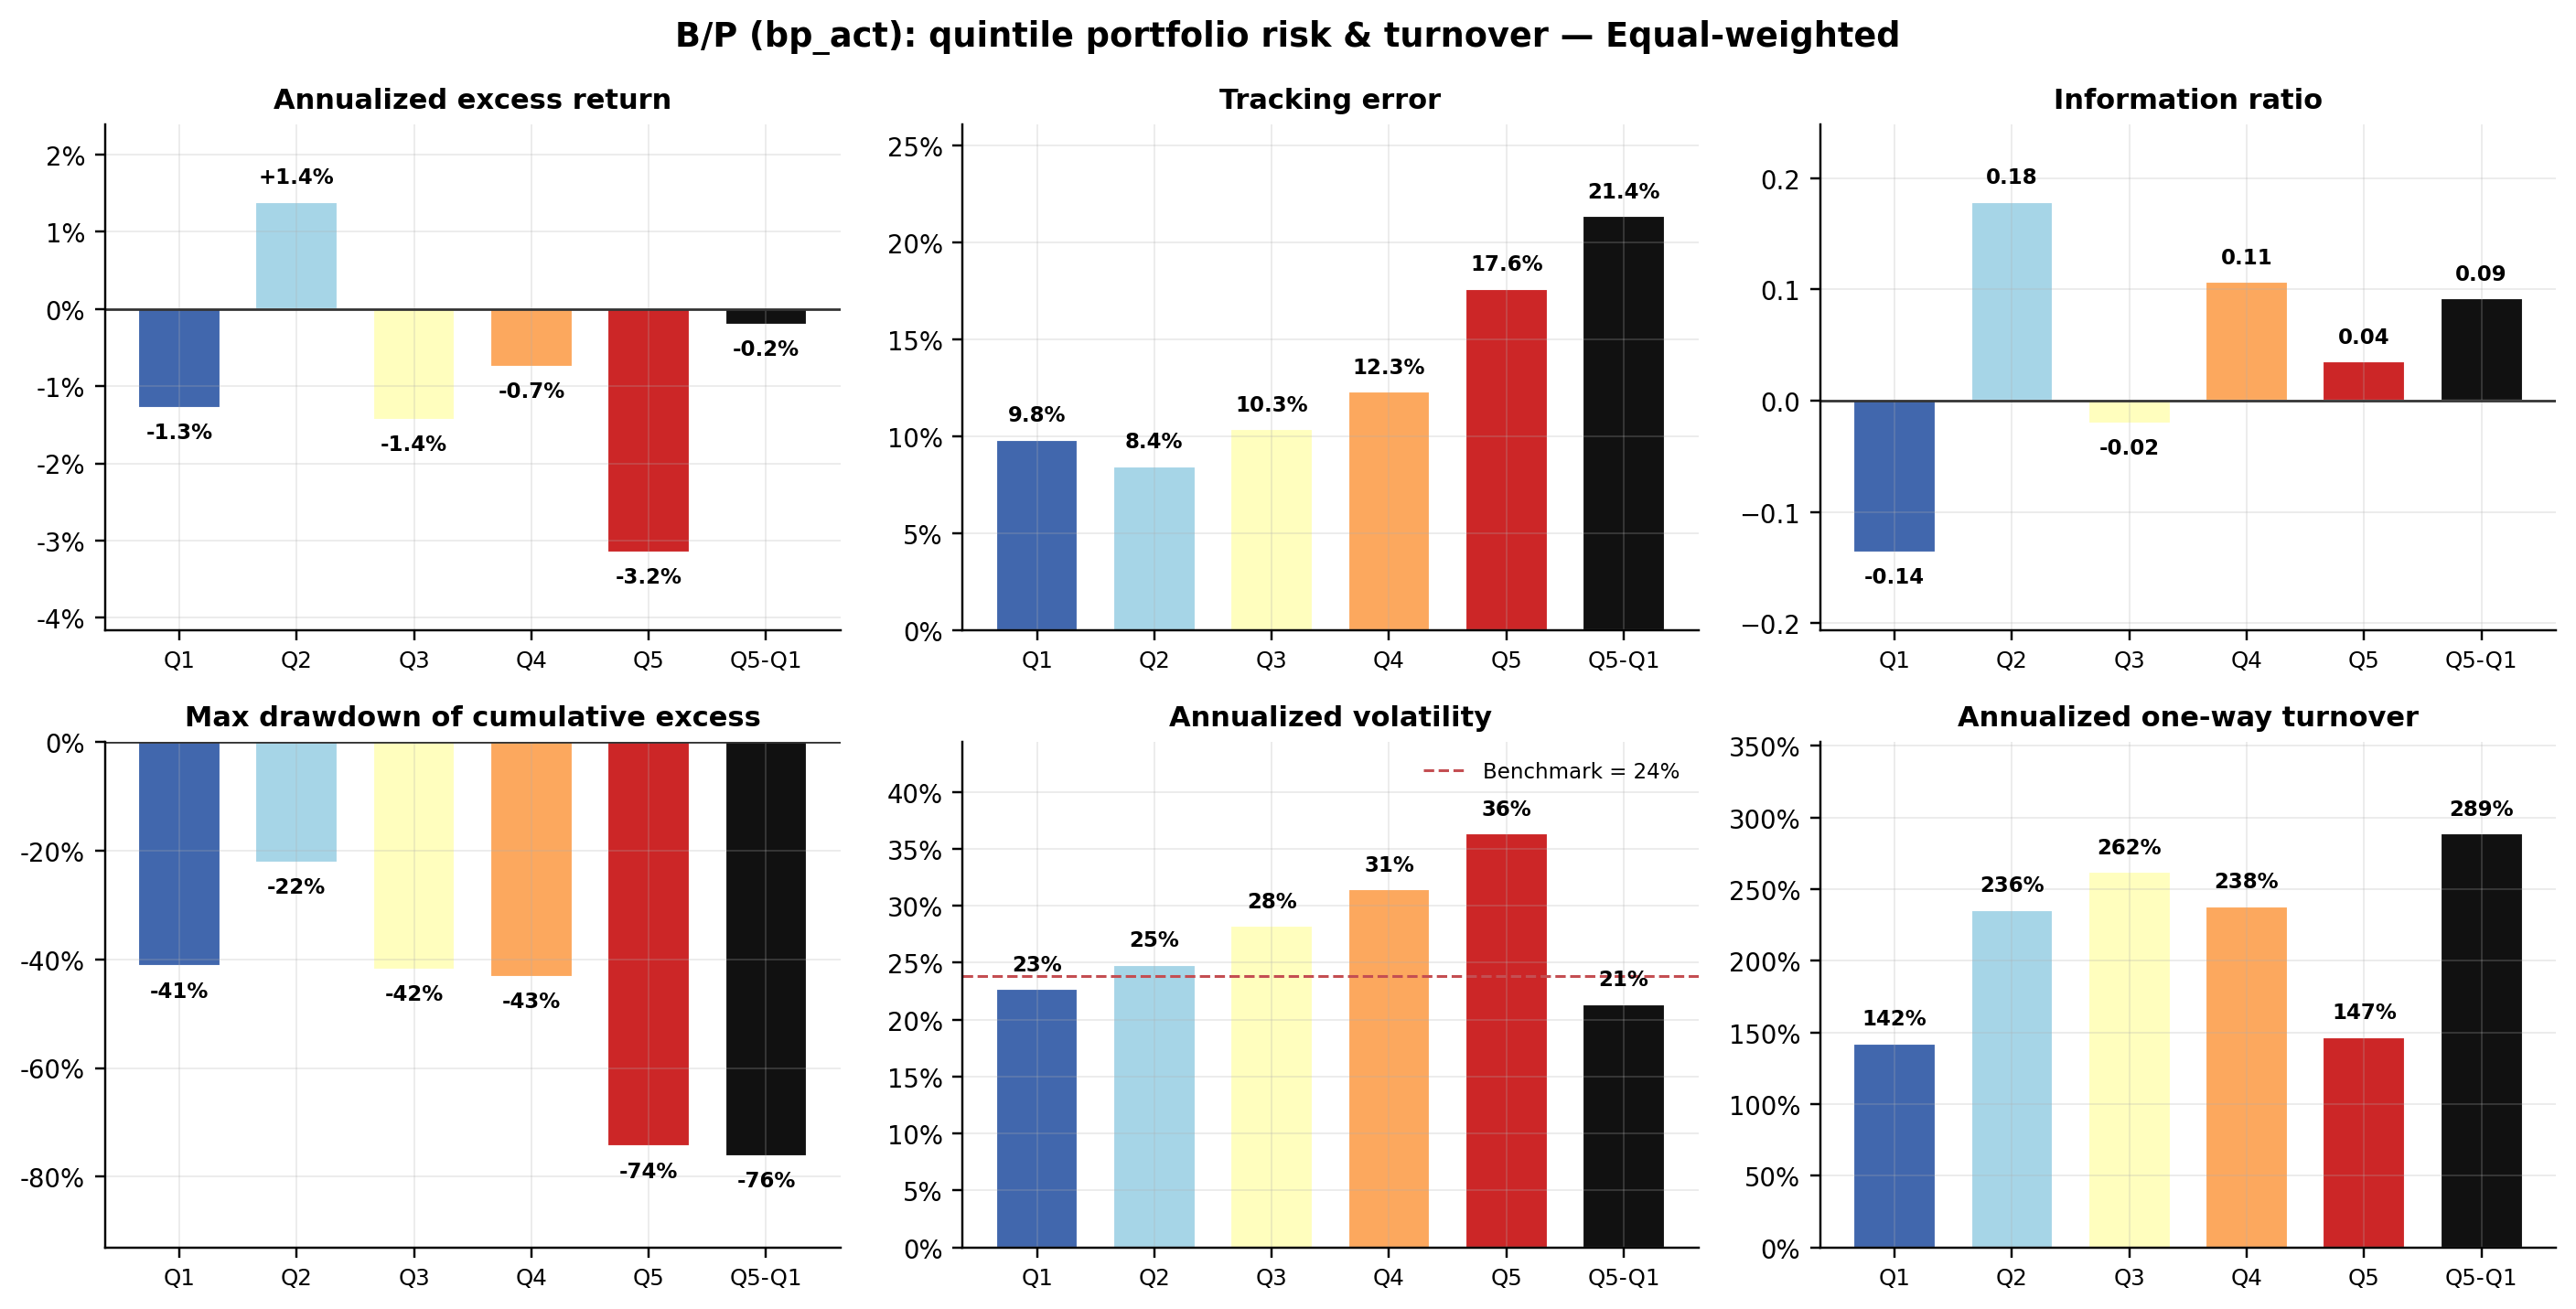

In [15]:
fig = fl.plotting.plot_quantile_dashboard(summaries["ew"], q=N_QUANTILE, factor=FACTOR_LABEL, weighting="ew")
fl.plotting.savefig(fig, "01_single_factor/08_quantile_dashboard_ew");


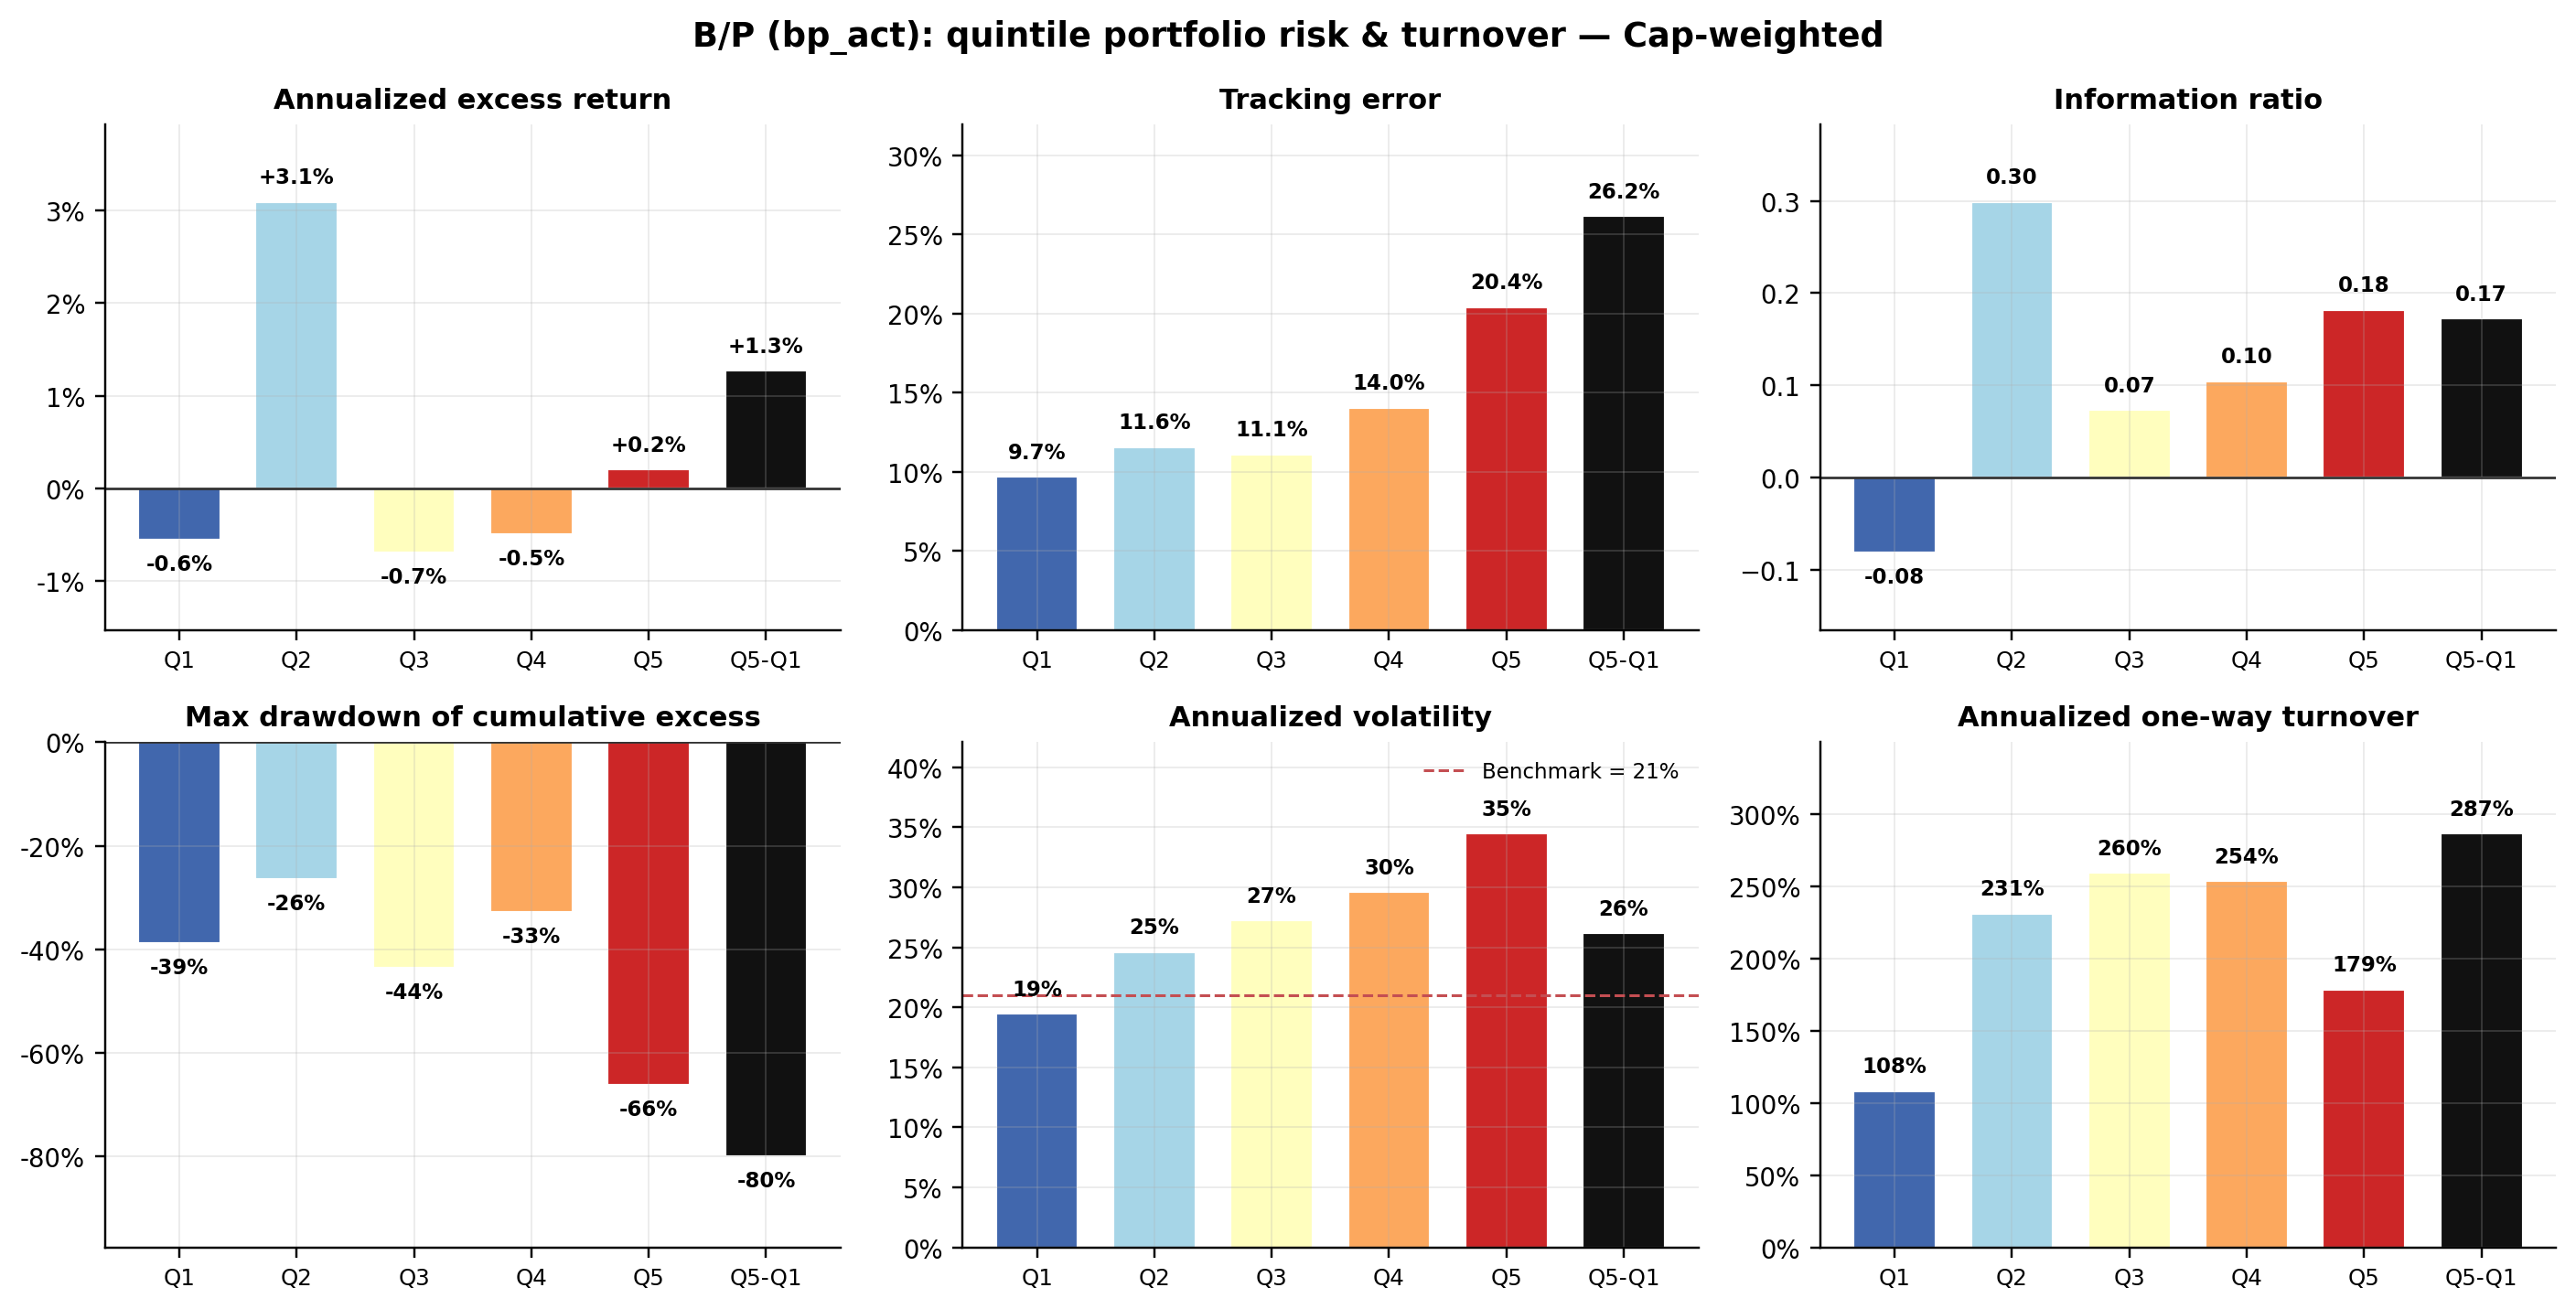

In [16]:
fig = fl.plotting.plot_quantile_dashboard(summaries["cw"], q=N_QUANTILE, factor=FACTOR_LABEL, weighting="cw")
fl.plotting.savefig(fig, "01_single_factor/09_quantile_dashboard_cw");


## 4. 別ファクターへの流用

前処理から分位分析まで 4 行で回せる。

In [17]:
def run_quantile(factor: str, label: str = "", method: str = "blom", q: int = 5,
                 ascending: bool = True, start: int = START, end: int = END):
    # ファクター名だけで 前処理 -> 分位分析 まで実行して (panel, res, summaries) を返す
    p = fl.data.build_panel([factor], start=start, end=end)
    p = fl.preprocess.standardize_panel(p, factor, method=method, winsor=None if method == "blom" else 0.01)
    r = fl.quantile.quantile_returns(p, f"{factor}_{method}", q=q, ascending=ascending)
    s = {w: fl.quantile.quantile_summary(r, weighting=w) for w in ("ew", "cw")}
    return p, r, s


_p, _r, _s = run_quantile("mom12_1", "Momentum (12-1M)")
_s["ew"]


,ann_return,ann_excess,ann_excess_arith,ann_vol,te,IR,t_stat_NW,hit_ratio,max_dd,max_dd_excess,turnover_1way,turnover_ann,name_turnover,n_stocks_mean,n_stocks_min
Q1,0.0035,-0.1078,-0.0639,0.3766,0.1918,-0.3333,-1.4892,0.4060,-0.7437,-0.8249,0.2787,3.3446,0.2490,72.4188,10.0000
Q2,0.0583,-0.0531,-0.0324,0.3086,0.1223,-0.2649,-1.0918,0.4017,-0.7042,-0.5739,0.4911,5.8936,0.4732,72.3846,10.0000
Q3,0.1292,0.0178,0.0223,0.2647,0.0846,0.2636,1.1765,0.5128,-0.6754,-0.3115,0.5225,6.2701,0.5058,72.4017,10.0000
Q4,0.1595,0.0481,0.0437,0.2417,0.0862,0.5072,2.4013,0.5641,-0.6913,-0.2361,0.4728,5.6740,0.4547,72.3846,10.0000
Q5,0.1579,0.0465,0.0474,0.2559,0.1178,0.4025,1.7887,0.5726,-0.7274,-0.4197,0.2642,3.1703,0.2340,72.4274,10.0000
Q5-Q1,0.0803,0.0803,0.1113,0.2383,0.2383,0.4673,1.9741,0.6197,-0.7158,-0.7158,0.5429,6.5149,NaN,NaN,NaN
NA,0.3862,0.2748,0.4405,0.8871,0.8701,0.5062,1.3518,0.4731,-0.6200,-0.6129,0.3190,3.8283,0.4027,0.5897,0.0000
bench,0.1114,NaN,NaN,0.2385,NaN,NaN,NaN,NaN,-0.6234,NaN,NaN,NaN,NaN,NaN,NaN


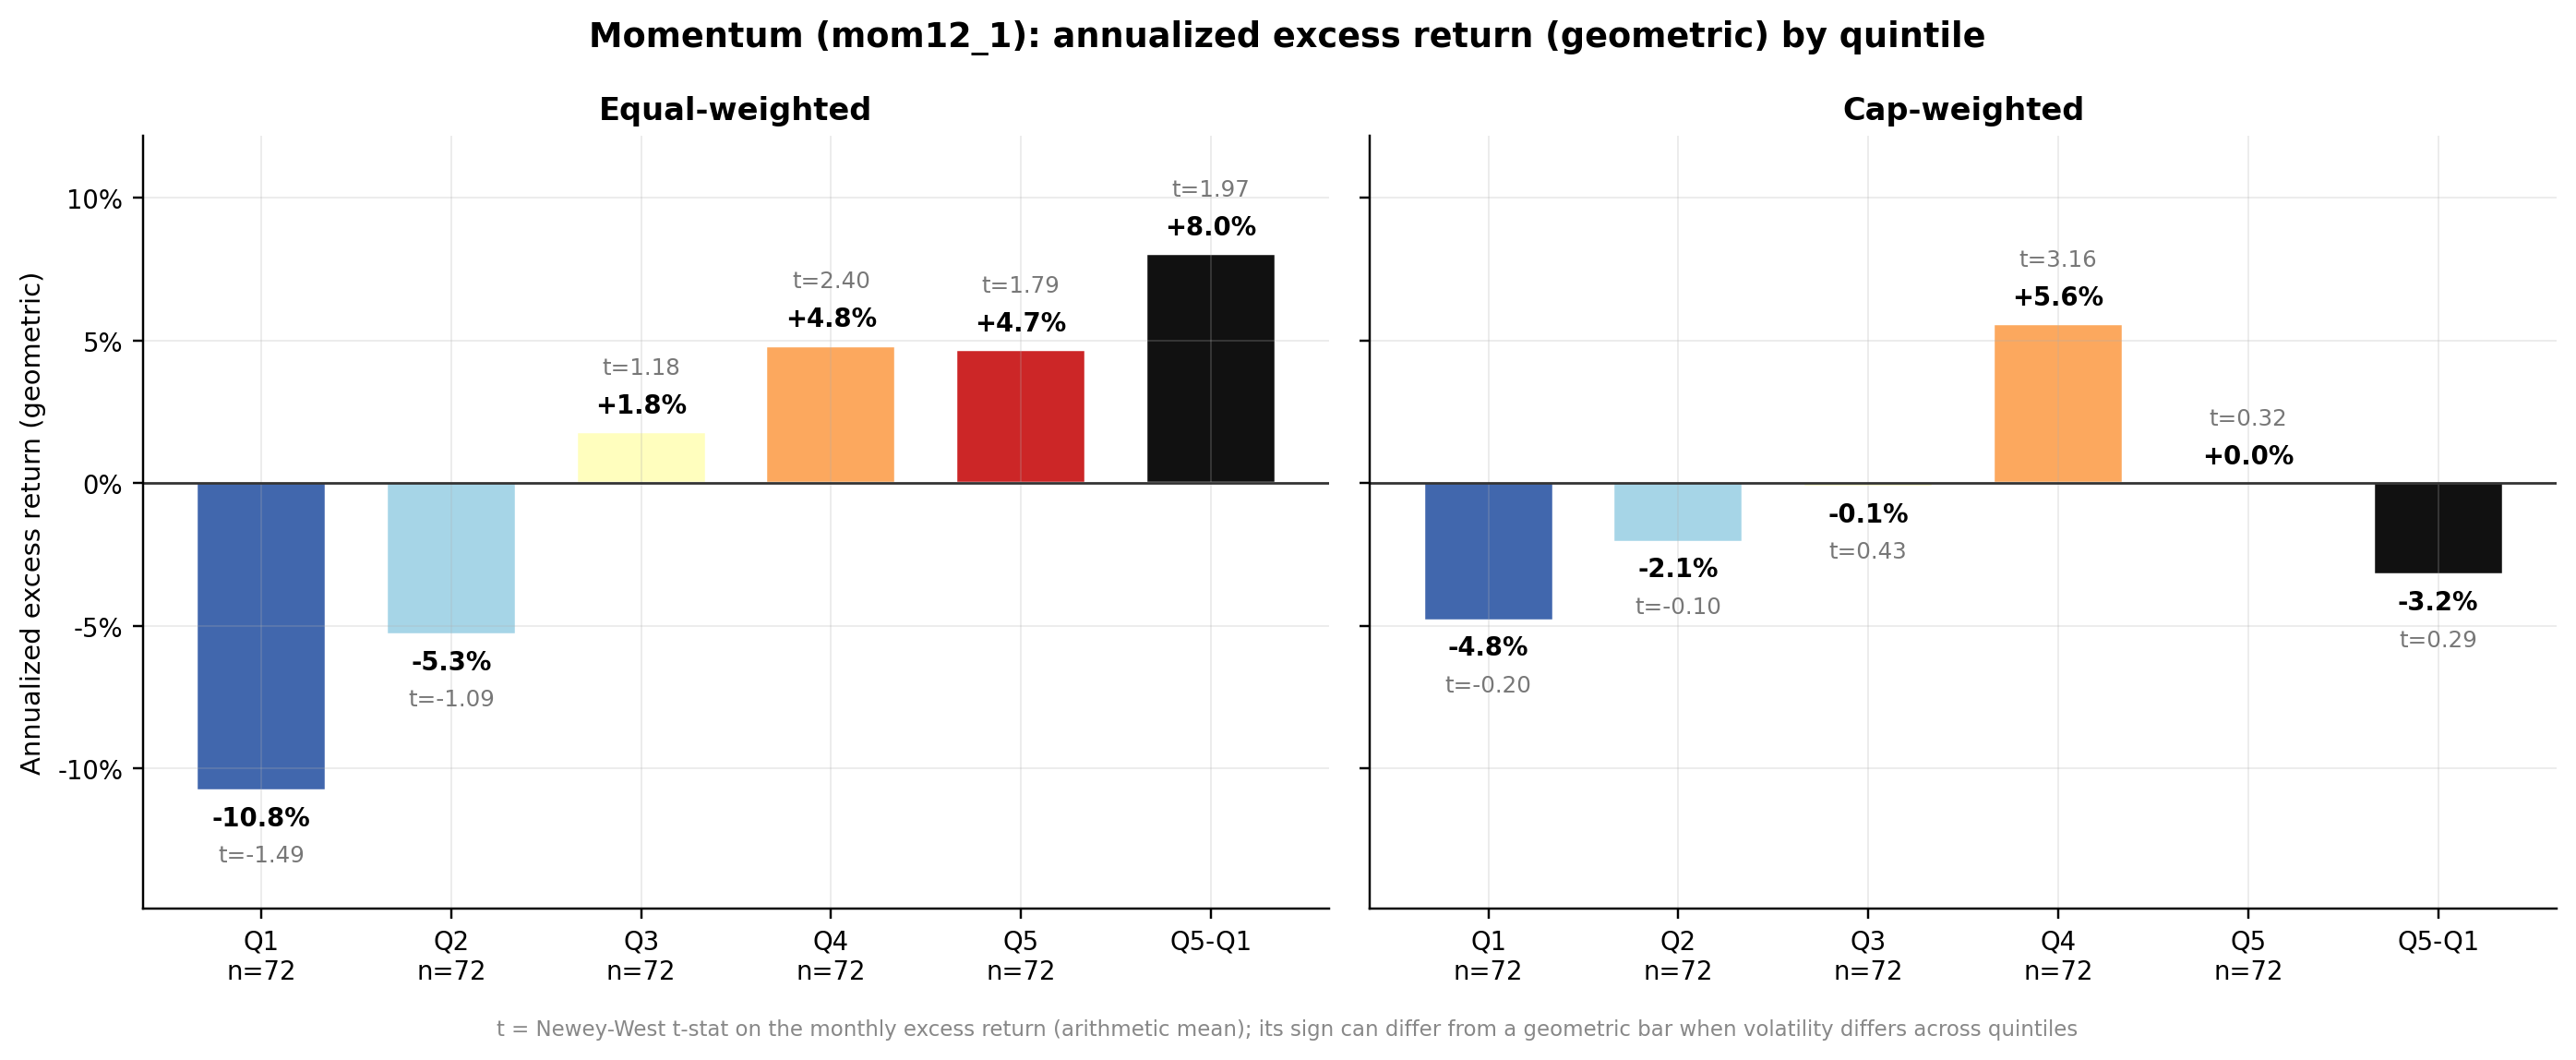

In [18]:
fig = fl.plotting.plot_quantile_panel(_r, _s, q=5, factor="Momentum (mom12_1)")
fl.plotting.savefig(fig, "01_single_factor/07_momentum_bar_both");


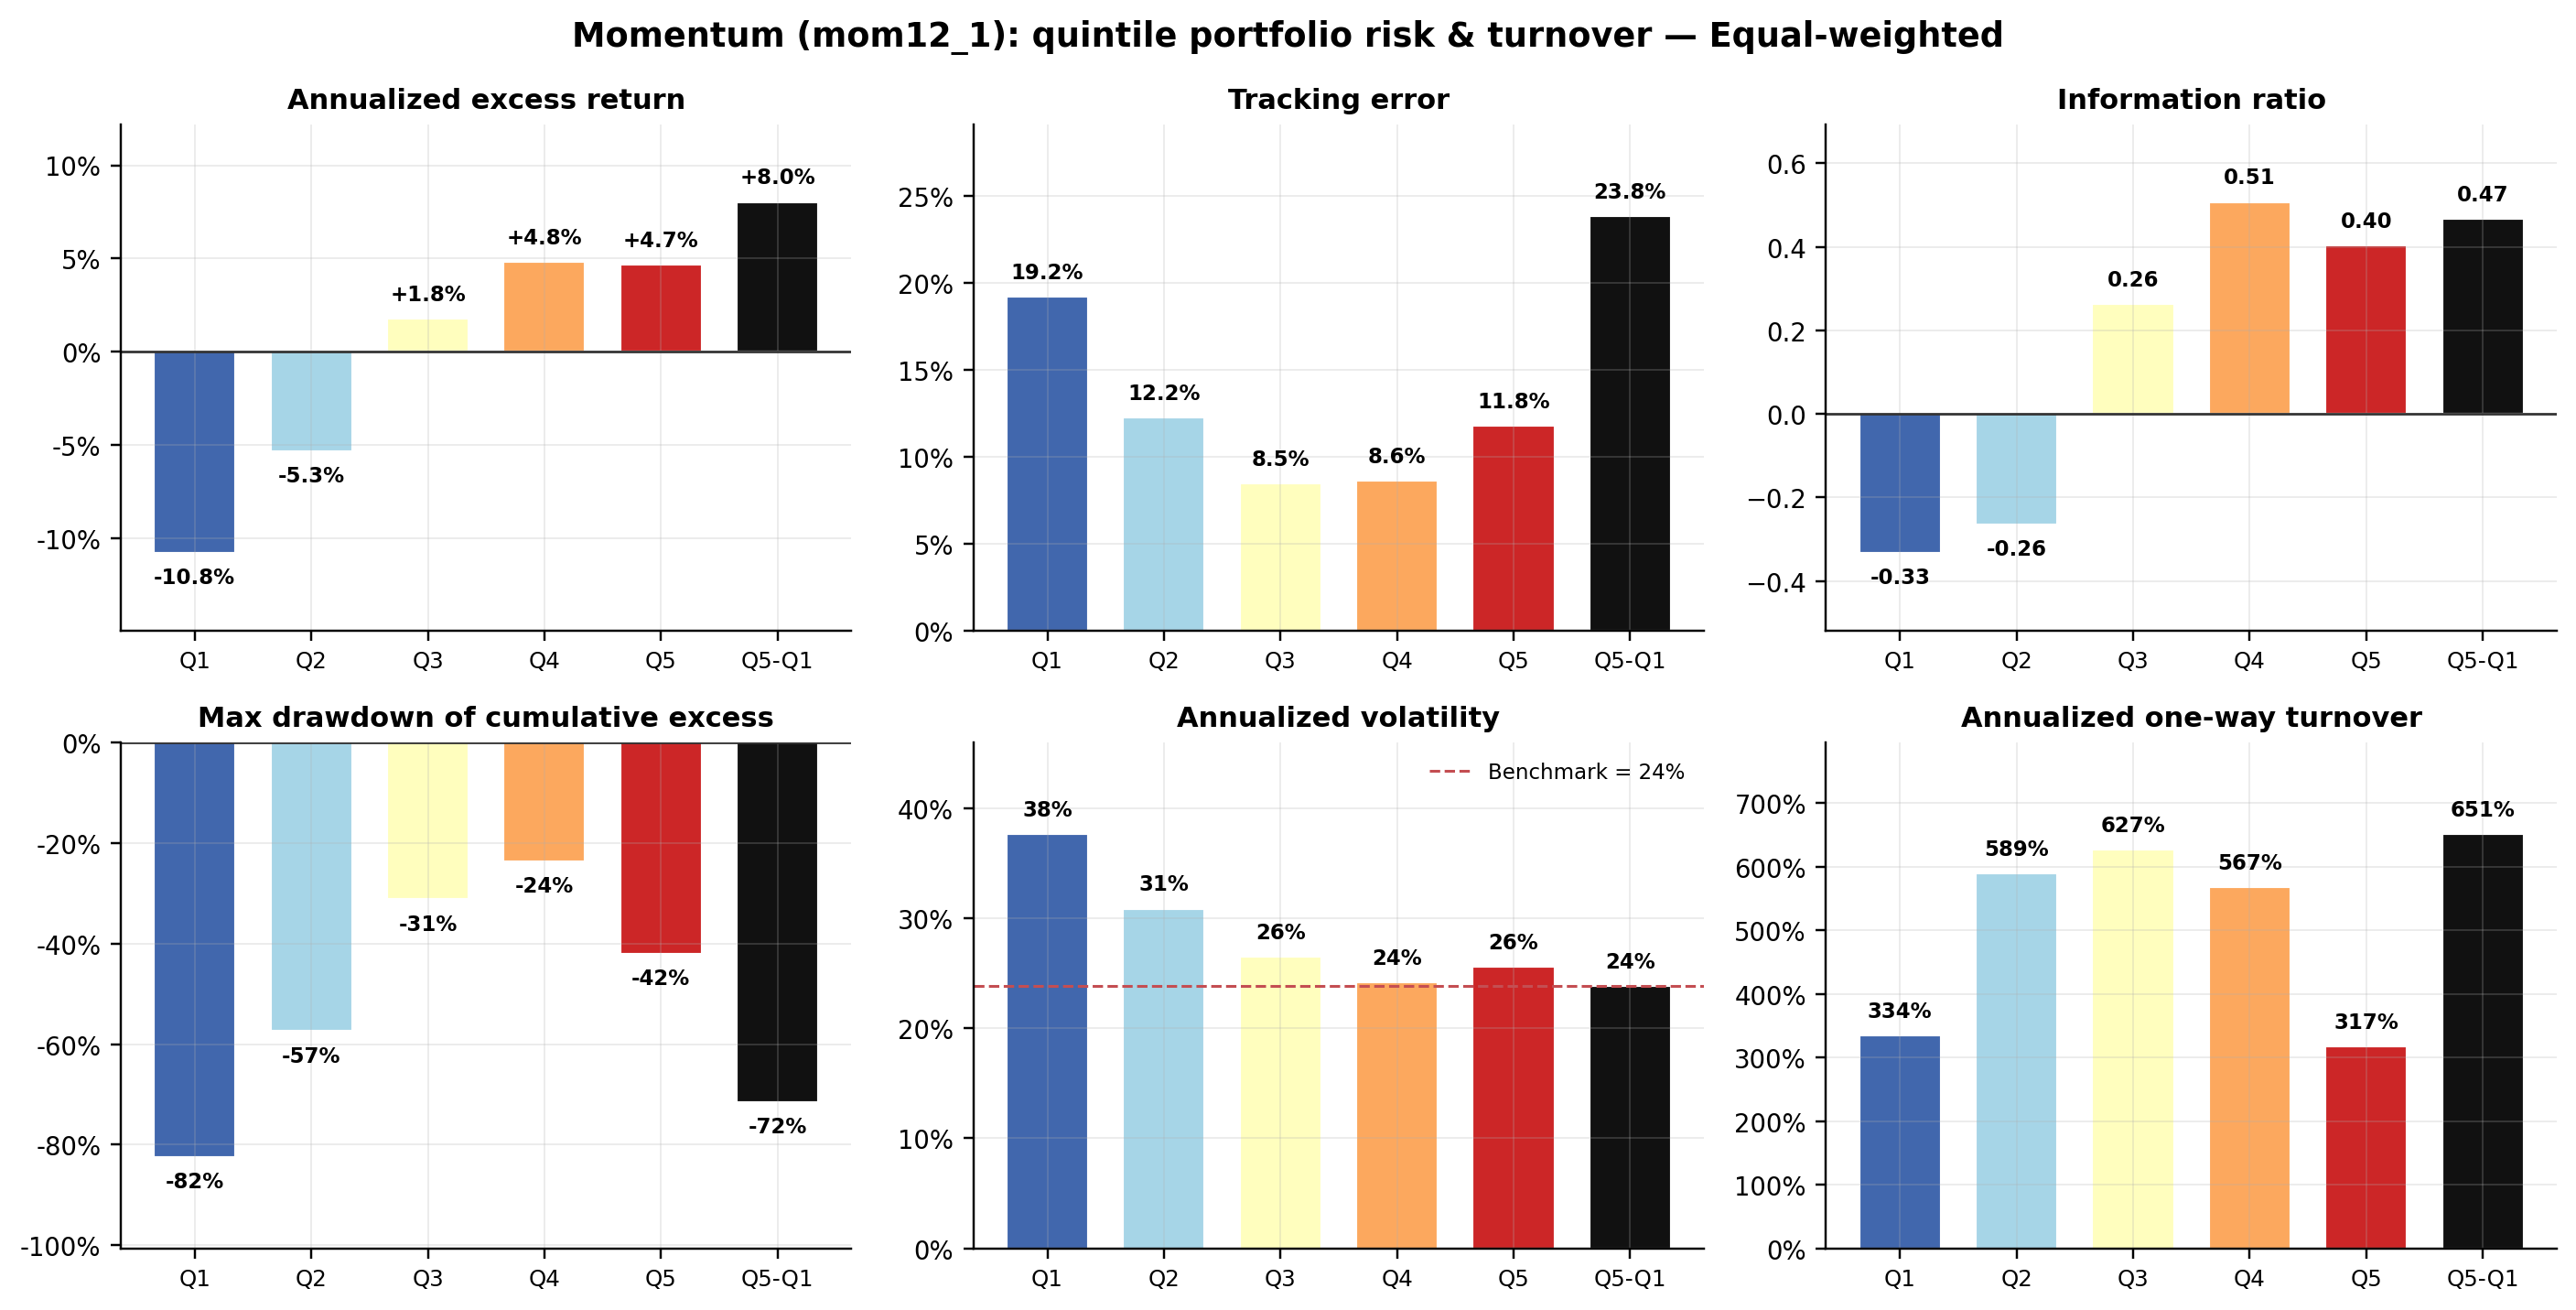

In [19]:
fig = fl.plotting.plot_quantile_dashboard(_s["ew"], q=5, factor="Momentum (mom12_1)", weighting="ew")
fl.plotting.savefig(fig, "01_single_factor/0A_momentum_dashboard_ew");


## 5. スコア欠損（NA）バケット

`quantile_returns` は既定で、**スコアが欠損している銘柄のバケット（列名 `"NA"`）**も
Q1〜Q5 と同じ物差し（EW/CW・対ベンチ超過・銘柄数・回転率）で計算する。

- 欠損は情報を持ち得る（`docs/tutorial` 2.2: 開示しない企業、カバレッジ外の小型株など）
- NA のパフォーマンスがベンチマークから大きく乖離する場合、
  「そのファクターを使う = 暗黙に NA 銘柄を外す」こと自体がベットになっている
- Q1〜Q5 + NA の銘柄数合計はユニバースの評価可能銘柄数と厳密に一致する（検証済み）

表示はオプトイン: 時系列は `show_na=True`（灰色破線）、棒は `include_na=True`（灰色バー）。
カバレッジ 34% の LTG で例示する。

In [20]:
p_ltg, r_ltg, s_ltg = run_quantile("ltg", "LTG (ltg)")

# NA バケットを含むサマリ（NA 行が自動で入る）
s_ltg["ew"].loc[["Q1", "Q5", "Q5-Q1", "NA", "bench"],
                ["ann_return", "ann_excess", "te", "IR", "t_stat_NW", "n_stocks_mean"]]


,ann_return,ann_excess,te,IR,t_stat_NW,n_stocks_mean
Q1,0.1039,-0.0075,0.0975,0.0174,0.0836,25.0000
Q5,0.1035,-0.0079,0.1117,0.0843,0.3452,25.0000
Q5-Q1,0.0011,0.0011,0.1150,0.0672,0.3048,NaN
NA,0.0922,-0.0192,0.1168,-0.0182,-0.0803,237.5385
bench,0.1114,NaN,NaN,NaN,NaN,NaN


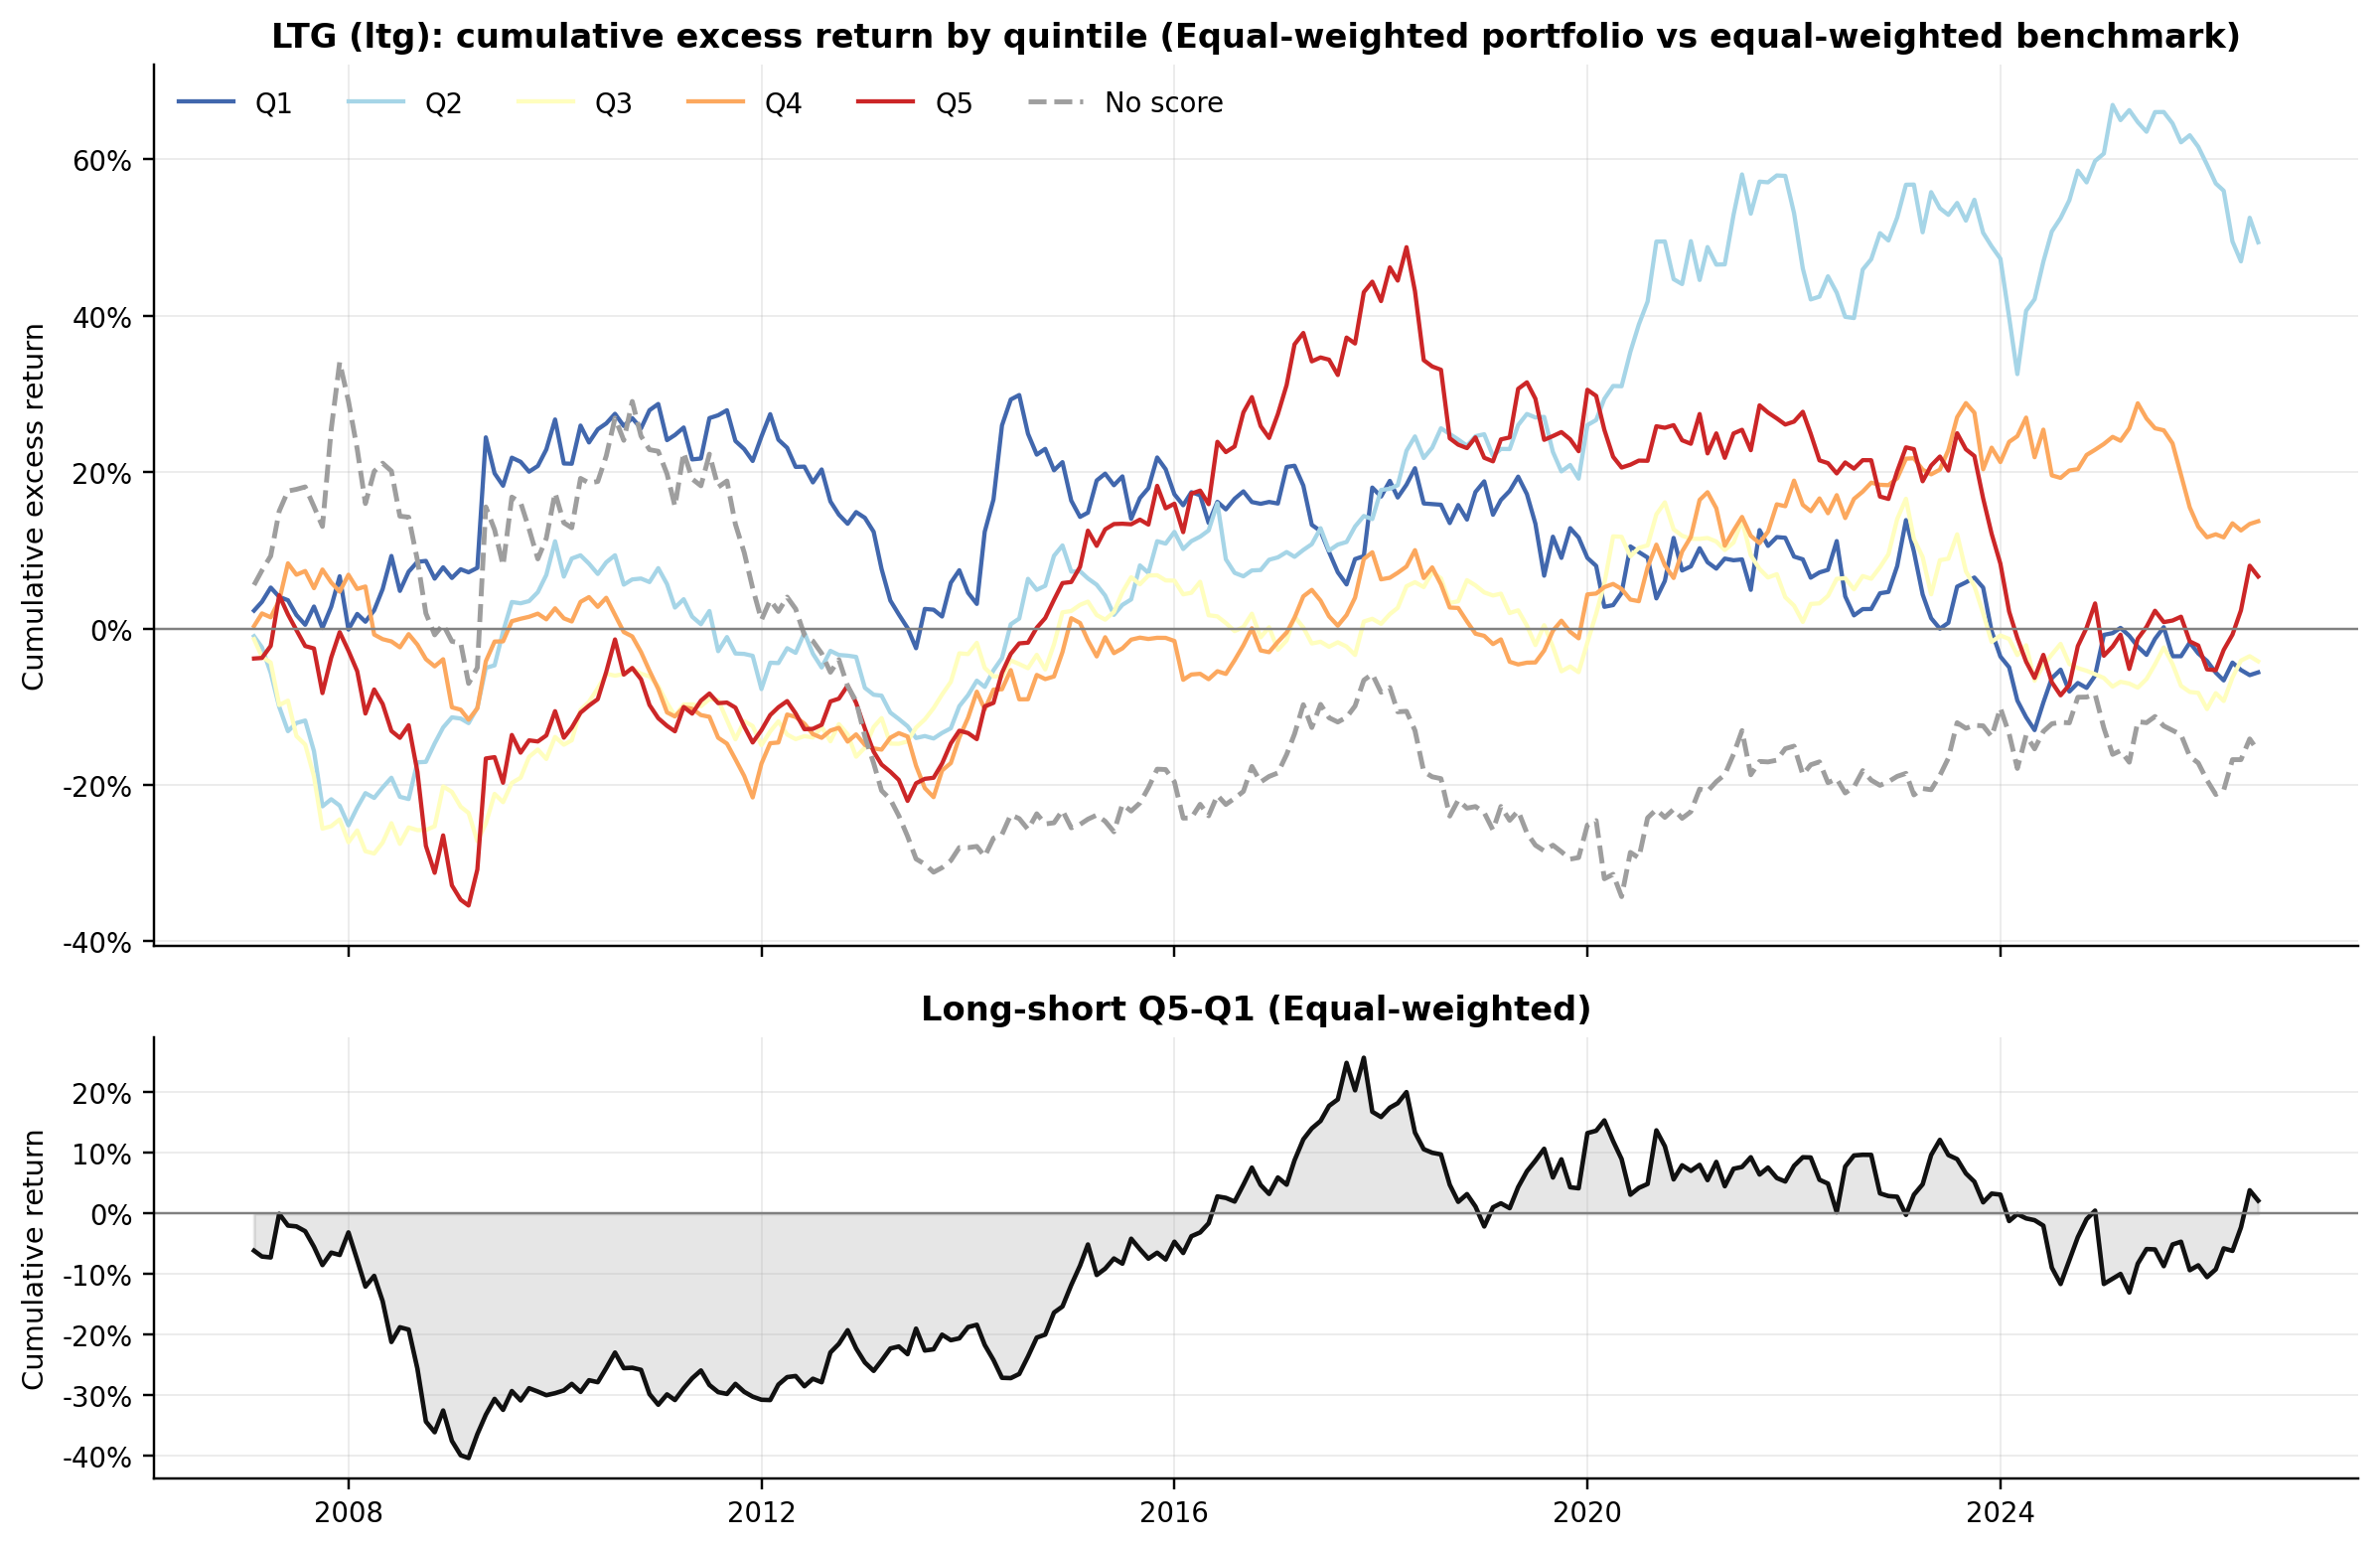

In [21]:
fig = fl.plotting.plot_quantile_timeseries(r_ltg, weighting="ew", q=5,
                                           factor="LTG (ltg)", show_na=True)
fl.plotting.savefig(fig, "01_single_factor/0B_ltg_quantile_ts_na");


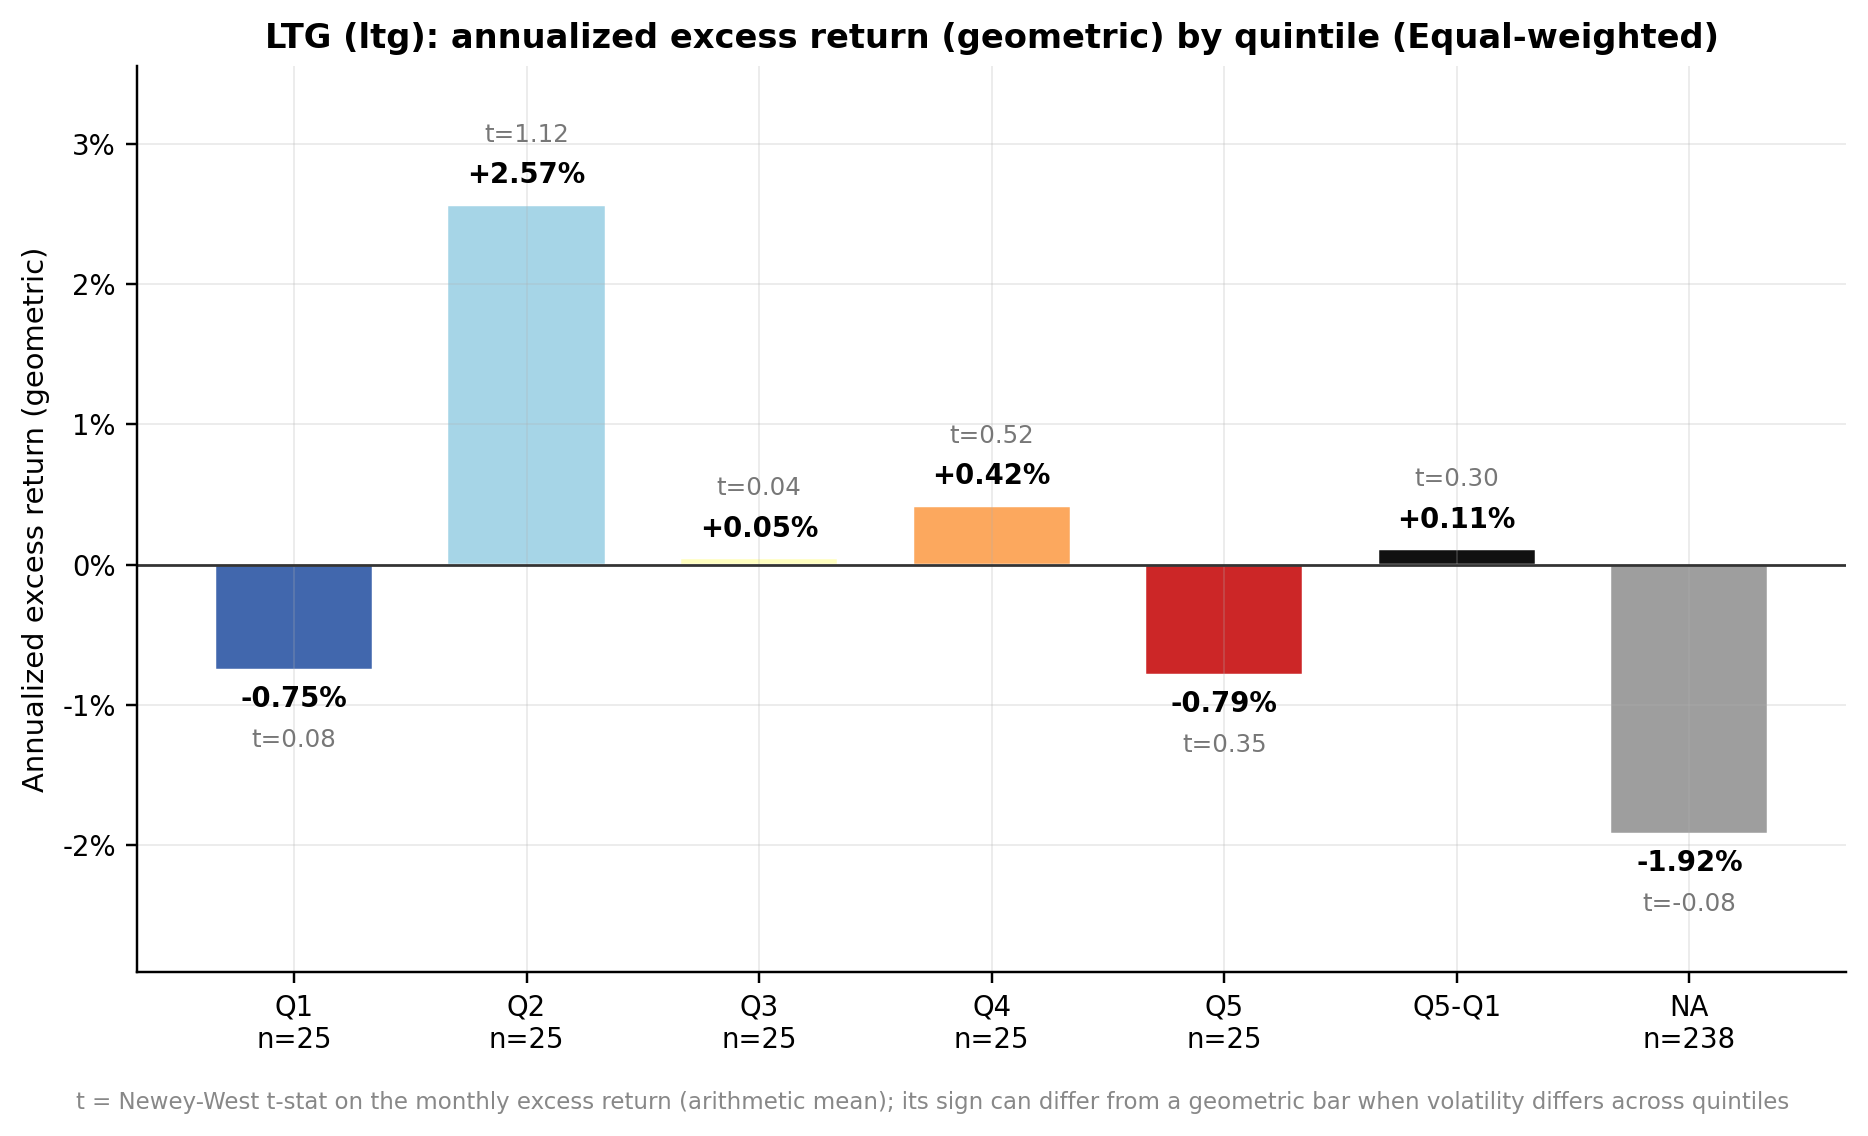

In [22]:
fig = fl.plotting.plot_quantile_bar(s_ltg["ew"], r_ltg["counts"], q=5,
                                    factor="LTG (ltg)", weighting="ew", include_na=True)
fl.plotting.savefig(fig, "01_single_factor/0C_ltg_quantile_bar_na");


---

## 次のステップ（Step 2 で追加予定）

- **IC**: 月次 IC の時系列（移動平均・累積）、IC 減衰（h = 1..12ヶ月）
- **ファクターリターン**: 翌月リターンをファクター1本に回帰した傾き $f_t$ の累積
  $$r_{i,t \to t+1} = a_t + f_t\, x_{i,t} + u_{i,t}$$

実装は `src/factorlab/ic.py` / `src/factorlab/regression.py` に用意済み。